# GitHub Repository Mining - Advanced Data Mining Project

This notebook is the complete academic artifact for the GitHub Repository Mining project. It covers the full grading rubric: real GitHub data collection, preprocessing, association rule mining, link analysis, visualization, real BERT/SentenceTransformer semantic analysis, recommendations, report conclusions, and presentation notes.

Current processed run:

| Metric | Value |
|---|---:|
| Repositories | 1000 |
| Technologies / topics | 3388 |
| Graph edges exported | 1500 |
| Association rules discovered | 265 |
| Technology communities | 3 |
| Semantic categories | 11 |

Generated at: `2026-05-11T07:18:45.166996+00:00`

Embedding method used in this local run: `BERT/NumPy BERT-Tiny: phob0s/bert-tiny`

## Phase 1. Secure GitHub API Runtime Setup

This notebook never stores a GitHub token in source code. At runtime, it can read `GITHUB_TOKEN` from the local environment or securely prompt for a Personal Access Token. Authentication is verified against GitHub's rate-limit endpoint before any live API collection runs.

For non-interactive validation only, set `DM_PROJECT_OFFLINE_VALIDATION=1` before executing the notebook. The notebook will then use the embedded real GitHub API dataset already bundled in the submission.

In [1]:
# @title Secure GitHub API Authentication { display-mode: "form" }
import getpass
import os
import sys

import requests

GITHUB_API_BASE = "https://api.github.com"
OFFLINE_VALIDATION = os.environ.get("DM_PROJECT_OFFLINE_VALIDATION") == "1"
REQUIRE_GITHUB_AUTH = globals().get("REQUIRE_GITHUB_AUTH", not OFFLINE_VALIDATION)
GITHUB_TOKEN = (globals().get("GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN") or "").strip()
GITHUB_AUTHENTICATED = False
GITHUB_RATE_LIMIT = {}

def github_headers():
    headers = {
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
        "User-Agent": "dm-project-notebook-miner",
    }
    if GITHUB_TOKEN:
        headers["Authorization"] = f"Bearer {GITHUB_TOKEN}"
    return headers

if REQUIRE_GITHUB_AUTH:
    if not GITHUB_TOKEN:
        GITHUB_TOKEN = getpass.getpass("Paste your GitHub Personal Access Token: ").strip()
    if not GITHUB_TOKEN:
        raise SystemExit("GitHub authentication failed: no token supplied.")

    response = requests.get(f"{GITHUB_API_BASE}/rate_limit", headers=github_headers(), timeout=30)
    if response.status_code != 200:
        raise SystemExit(f"GitHub authentication failed with HTTP {response.status_code}. Check the token and rerun.")

    rate_payload = response.json()
    GITHUB_RATE_LIMIT = rate_payload.get("resources", {}).get("core", {})
    GITHUB_AUTHENTICATED = True
    print("GitHub authentication verified.")
    print("Core API remaining requests:", GITHUB_RATE_LIMIT.get("remaining", "unknown"))
    print("Core API reset epoch:", GITHUB_RATE_LIMIT.get("reset", "unknown"))
else:
    print("GitHub authentication skipped for offline validation mode.")
    print("The analysis will use the embedded real GitHub API dataset already saved in the notebook.")

GitHub authentication skipped for offline validation mode.
The analysis will use the embedded real GitHub API dataset already saved in the notebook.


## Phase 2. Interactive Live GitHub Collection GUI

This cell builds the live-collection notebook GUI for target keywords, minimum stars, preferred languages, and repository limit. When authentication is active, the same function can fetch live GitHub Search API metadata with pagination, exponential backoff, language enrichment, README retrieval for the highest-star repositories, and local reproducibility saves.

In [2]:
# @title Live GitHub Search GUI and Collector { display-mode: "form" }
import base64
import json
import time
from pathlib import Path

import pandas as pd
import requests

LIVE_SEARCH_KEYWORDS = globals().get("LIVE_SEARCH_KEYWORDS", "machine learning data science")
LIVE_MIN_STARS = int(globals().get("LIVE_MIN_STARS", 500))
LIVE_LANGUAGES = globals().get("LIVE_LANGUAGES", "Python, JavaScript, TypeScript")
LIVE_MAX_REPOS = int(globals().get("LIVE_MAX_REPOS", 50))
LIVE_README_LIMIT = int(globals().get("LIVE_README_LIMIT", 10))
AUTO_RUN_GITHUB_SEARCH = globals().get("AUTO_RUN_GITHUB_SEARCH", GITHUB_AUTHENTICATED and not OFFLINE_VALIDATION)
LIVE_REPOS_DF = None

def github_api_json(url, params=None, max_attempts=5):
    for attempt in range(max_attempts):
        response = requests.get(url, params=params, headers=github_headers(), timeout=30)
        remaining = response.headers.get("X-RateLimit-Remaining")
        reset = response.headers.get("X-RateLimit-Reset")

        if response.status_code in {403, 429}:
            if remaining == "0" and reset:
                wait = max(5, int(reset) - int(time.time()) + 3)
            else:
                wait = min(60, 2 ** attempt * 5)
            print(f"GitHub rate/throttle response {response.status_code}. Sleeping {wait}s.")
            time.sleep(wait)
            continue

        if response.status_code >= 500:
            wait = min(60, 2 ** attempt * 3)
            print(f"GitHub server response {response.status_code}. Retrying in {wait}s.")
            time.sleep(wait)
            continue

        response.raise_for_status()
        return response.json(), response.headers

    raise RuntimeError(f"GitHub API request failed after {max_attempts} attempts: {url}")

def fetch_repo_languages(full_name):
    try:
        payload, _ = github_api_json(f"{GITHUB_API_BASE}/repos/{full_name}/languages")
        if isinstance(payload, dict):
            return sorted(payload, key=payload.get, reverse=True)
    except Exception:
        return []
    return []

def fetch_readme_text(full_name):
    try:
        payload, _ = github_api_json(f"{GITHUB_API_BASE}/repos/{full_name}/readme")
        content = payload.get("content", "") if isinstance(payload, dict) else ""
        if not content:
            return ""
        return base64.b64decode(content).decode("utf-8", errors="ignore")[:6000]
    except Exception:
        return ""

def search_live_github_repositories(keywords, min_stars, languages, max_repos, readme_limit=10):
    if not GITHUB_AUTHENTICATED:
        raise RuntimeError("Authenticate with GitHub before live collection.")

    terms = " ".join(str(keywords or "").split())
    language_list = [item.strip() for item in str(languages or "").split(",") if item.strip()]
    queries = []
    if language_list:
        for language in language_list:
            queries.append(f"{terms} language:{language} stars:>={int(min_stars)}")
    else:
        queries.append(f"{terms} stars:>={int(min_stars)}")

    repos_by_name = {}
    for query in queries:
        page = 1
        while len(repos_by_name) < int(max_repos) and page <= 10:
            payload, headers = github_api_json(
                f"{GITHUB_API_BASE}/search/repositories",
                {
                    "q": query,
                    "sort": "stars",
                    "order": "desc",
                    "per_page": min(100, int(max_repos)),
                    "page": page,
                },
            )
            items = payload.get("items", []) if isinstance(payload, dict) else []
            if not items:
                break
            for item in items:
                full_name = item.get("full_name")
                if not full_name or full_name in repos_by_name:
                    continue
                repos_by_name[full_name] = {
                    "name": full_name,
                    "description": item.get("description") or "",
                    "stars": item.get("stargazers_count", 0),
                    "forks": item.get("forks_count", 0),
                    "watchers": item.get("watchers_count", 0),
                    "open_issues": item.get("open_issues_count", 0),
                    "language": item.get("language") or "Unknown",
                    "languages": [],
                    "topics": item.get("topics") or [],
                    "html_url": item.get("html_url"),
                    "archived": bool(item.get("archived")),
                    "pushed_at": (item.get("pushed_at") or "")[:10],
                    "created_at": (item.get("created_at") or "")[:10],
                    "readme": "",
                    "data_origin": "github_api_live_notebook",
                }
                if len(repos_by_name) >= int(max_repos):
                    break
            page += 1

    records = sorted(repos_by_name.values(), key=lambda repo: (-int(repo["stars"]), repo["name"]))
    for repo in records[: max(0, int(readme_limit))]:
        repo["languages"] = fetch_repo_languages(repo["name"])
        repo["readme"] = fetch_readme_text(repo["name"])

    df = pd.DataFrame(records)
    out_dir = Path("data/raw")
    out_dir.mkdir(parents=True, exist_ok=True)
    df.to_json(out_dir / "notebook_live_github_repos.json", orient="records", indent=1, force_ascii=False)
    df.to_csv(out_dir / "notebook_live_github_repos.csv", index=False)
    print(f"Saved live collection: {out_dir / 'notebook_live_github_repos.json'}")
    print(f"Remaining search quota header: {headers.get('X-RateLimit-Remaining', 'unknown') if records else 'unknown'}")
    return df

try:
    import ipywidgets as widgets
    from IPython.display import display

    keyword_widget = widgets.Text(value=LIVE_SEARCH_KEYWORDS, description="Keywords")
    stars_widget = widgets.IntSlider(value=LIVE_MIN_STARS, min=0, max=5000, step=100, description="Min stars")
    languages_widget = widgets.Text(value=LIVE_LANGUAGES, description="Languages")
    limit_widget = widgets.BoundedIntText(value=LIVE_MAX_REPOS, min=1, max=1000, description="Max repos")
    run_button = widgets.Button(description="Fetch GitHub Data", button_style="primary")
    output = widgets.Output()

    def run_live_collection(_):
        global LIVE_REPOS_DF
        with output:
            output.clear_output()
            LIVE_REPOS_DF = search_live_github_repositories(
                keyword_widget.value,
                stars_widget.value,
                languages_widget.value,
                limit_widget.value,
                LIVE_README_LIMIT,
            )
            display(LIVE_REPOS_DF.head(10))

    run_button.on_click(run_live_collection)
    display(widgets.VBox([keyword_widget, stars_widget, languages_widget, limit_widget, run_button, output]))
except Exception as exc:
    print("Interactive widgets are unavailable in this environment:", exc)

if AUTO_RUN_GITHUB_SEARCH:
    LIVE_REPOS_DF = search_live_github_repositories(
        LIVE_SEARCH_KEYWORDS,
        LIVE_MIN_STARS,
        LIVE_LANGUAGES,
        LIVE_MAX_REPOS,
        LIVE_README_LIMIT,
    )
    display(LIVE_REPOS_DF.head(10))
else:
    print("Live GitHub search was not auto-run.")
    print("Set AUTO_RUN_GITHUB_SEARCH=True after authentication to fetch fresh live data from this cell.")

Live GitHub search was not auto-run.
Set AUTO_RUN_GITHUB_SEARCH=True after authentication to fetch fresh live data from this cell.


## Rubric Coverage

| Requirement | Marks | Where it is covered |
|---|---:|---|
| Data Collection & GUI | 1 or 2 | GitHub API collector, embedded real dataset, raw schema, dataset profile, dashboard GUI |
| Data Preprocessing | 1 or 2 | Text cleaning, topic normalization, feature engineering |
| Association Rule Mining | 2 or 3 | Apriori rules, optional FP-Growth, support, confidence, lift, stack recommendations |
| Link Analysis (PageRank/HITS) | 2 or 3 | Technology PageRank/HITS and repository influence graph |
| Visualization | 1 | EDA charts, rule plots, PageRank plots, graph-ready exports |
| Report and presentation | 1 | Final insights, limitations, presentation outline |
| BERT | 5 | Text classification, semantic embeddings, clusters, similarity recommendations |

The dashboard app in `app/` is the GUI deliverable. This notebook is the detailed explanation and analysis deliverable.

## Required Grading Sections

This notebook explicitly includes every requested grading section:

- **Data Collection & GUI**: GitHub collection design, embedded real GitHub API dataset, raw data inspection, dashboard evidence.
- **Data Preprocessing**: cleaning, normalization, transaction construction, quality checks, schema validation.
- **Association Rule Mining**: Apriori rules, support/confidence/lift/conviction/leverage, FP-Growth comparison when available.
- **Visualization**: language/category charts, distribution plots, heatmaps, rule plots, graph charts, semantic cluster plots.
- **Link Analysis (PageRank/HITS)**: technology graph PageRank/HITS and repository influence graph PageRank/HITS.

## 1. Project Architecture and Run Commands

The project can run in two real-data modes:

1. Real GitHub collection mode using `scripts/collect_data.py` with an optional `GITHUB_TOKEN`.
2. One-notebook Colab mode using the embedded real GitHub API dataset already saved inside this notebook.

The same analysis pipeline processes both sources.

In [3]:
from pathlib import Path

PROJECT_ROOT_OVERRIDE = globals().get("PROJECT_ROOT_OVERRIDE", None)
EMBEDDED_REAL_PROJECT_B64 = globals().get("EMBEDDED_REAL_PROJECT_B64", "")

print("This notebook can run as one uploaded file in Colab.")
print("If project data is missing, it will restore embedded real GitHub API data automatically.")
print("Optional override if you have the full project folder:")
print('PROJECT_ROOT_OVERRIDE = "/content/DM_Project"')

print("\nReal GitHub data commands:")
print("export GITHUB_TOKEN=your_token_here")
print("python3 scripts/collect_data.py --target 30000 --readme-limit 1500")
print("python3 scripts/run_pipeline.py")

print("\nProcess collected real data:")
print("python3 scripts/run_pipeline.py")
print("python3 scripts/build_notebook.py")
print("python3 scripts/validate_project.py")
print("python3 -m http.server 8080")
print("Open http://127.0.0.1:8080/app/")

This notebook can run as one uploaded file in Colab.
If project data is missing, it will restore embedded real GitHub API data automatically.
Optional override if you have the full project folder:
PROJECT_ROOT_OVERRIDE = "/content/DM_Project"

Real GitHub data commands:
export GITHUB_TOKEN=your_token_here
python3 scripts/collect_data.py --target 30000 --readme-limit 1500
python3 scripts/run_pipeline.py

Process collected real data:
python3 scripts/run_pipeline.py
python3 scripts/build_notebook.py
python3 scripts/validate_project.py
python3 -m http.server 8080
Open http://127.0.0.1:8080/app/


## 2. Environment Setup

The notebook mainly reads processed JSON outputs, so it remains fast even for large datasets. For one-file Colab submission, this notebook carries the current real GitHub API dataset and dashboard files inside an embedded bundle.

In [4]:
# @title Embedded Real GitHub API Project Bundle { display-mode: "form" }
EMBEDDED_REAL_PROJECT_B64 = """..."""

In [5]:
# @title Environment Setup { display-mode: "form" }
import base64
import json
import math
import os
import re
import subprocess
import sys
import warnings
import zipfile
import zlib
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning, module=r"jupyter_client\..*")
warnings.filterwarnings("ignore", message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*")

try:
    from IPython.display import display, Markdown
except Exception:
    display = print

PROJECT_ROOT_OVERRIDE = globals().get("PROJECT_ROOT_OVERRIDE", None)

def bounded_find(base, relative_marker, max_depth=5):
    base = Path(base)
    if not base.exists():
        return None
    marker_parts = Path(relative_marker).parts
    for root, dirs, files in os.walk(base):
        root_path = Path(root)
        depth = len(root_path.relative_to(base).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        if marker_parts[-1] not in files:
            continue
        marker = root_path / marker_parts[-1]
        if str(marker).endswith(str(Path(relative_marker))):
            return marker.parents[len(marker_parts) - 1]
    return None

def unpack_project_zip_if_present():
    if not Path("/content").exists():
        return None
    for zip_path in [Path("/content/DM_Project_colab.zip"), Path("/content/DM_Project.zip"), Path("/content/project.zip")]:
        if zip_path.exists():
            target = Path("/content/DM_Project")
            if not (target / "data" / "processed" / "stats.json").exists() and not (target / "scripts" / "run_pipeline.py").exists():
                print(f"Found {zip_path}. Extracting to {target} ...")
                target.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(zip_path) as zf:
                    zf.extractall(target)
            nested = target / "DM_Project"
            if (nested / "data" / "processed" / "stats.json").exists() or (nested / "scripts" / "run_pipeline.py").exists():
                return nested
            if (target / "data" / "processed" / "stats.json").exists() or (target / "scripts" / "run_pipeline.py").exists():
                return target
    return None

def upload_project_zip_in_colab():
    if not Path("/content").exists():
        return None
    try:
        from google.colab import files
    except Exception:
        return None

    print("Missing project data. Please upload DM_Project_colab.zip when the upload button appears.")
    uploaded = files.upload()
    if not uploaded:
        return None
    for filename, content in uploaded.items():
        if not filename.endswith(".zip"):
            continue
        zip_path = Path("/content") / filename
        zip_path.write_bytes(content)
        print(f"Uploaded {filename}. Extracting ...")
        return unpack_project_zip_if_present()
    return None

def find_project_root():
    candidates = []
    if PROJECT_ROOT_OVERRIDE:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE).expanduser())
    extracted = unpack_project_zip_if_present()
    if extracted:
        candidates.append(extracted)
    cwd = Path.cwd()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path("/content/DM_Project"),
        Path("/content/drive/MyDrive/DM_Project"),
        Path.home() / "Downloads" / "DM_Project",
    ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "data" / "processed" / "stats.json").exists():
            return candidate
        if (candidate / "scripts" / "run_pipeline.py").exists():
            return candidate

    for base in [Path("/content"), Path("/content/drive/MyDrive")]:
        found = bounded_find(base, "data/processed/stats.json", max_depth=5)
        if found:
            return found
        found = bounded_find(base, "scripts/run_pipeline.py", max_depth=5)
        if found:
            return found
    return cwd

ROOT = find_project_root()
PROCESSED = ROOT / "data" / "processed"
RAW_PATH = ROOT / "data" / "raw" / "github_repos.json"

def refresh_project_root():
    global ROOT, PROCESSED, RAW_PATH
    new_root = find_project_root()
    if new_root != ROOT:
        ROOT = new_root
        PROCESSED = ROOT / "data" / "processed"
        RAW_PATH = ROOT / "data" / "raw" / "github_repos.json"
        print("Updated project root:", ROOT)
    return ROOT

def build_processed_data_if_possible():
    global ROOT, PROCESSED, RAW_PATH
    refresh_project_root()
    stats_path = PROCESSED / "stats.json"
    if stats_path.exists():
        return True

    pipeline = ROOT / "scripts" / "run_pipeline.py"
    if not pipeline.exists():
        return False

    print("Processed data missing. Running scripts/run_pipeline.py ...")
    subprocess.run([sys.executable, str(pipeline)], cwd=str(ROOT), check=True)
    return stats_path.exists()

def extract_embedded_real_project_if_possible():
    # Restore the real GitHub API dataset and GUI files embedded in this notebook.
    global ROOT, PROCESSED, RAW_PATH
    if (PROCESSED / "stats.json").exists():
        return True
    if not EMBEDDED_REAL_PROJECT_B64:
        return False

    target = Path("/content/DM_Project") if Path("/content").exists() else Path.cwd() / "DM_Project_real"
    ROOT = target
    PROCESSED = ROOT / "data" / "processed"
    RAW_PATH = ROOT / "data" / "raw" / "github_repos.json"
    ROOT.mkdir(parents=True, exist_ok=True)

    try:
        payload = zlib.decompress(base64.b64decode(EMBEDDED_REAL_PROJECT_B64.encode("ascii"))).decode("utf-8")
        bundle = json.loads(payload)
    except Exception as exc:
        print("Could not restore embedded real project bundle:", exc)
        return False

    for rel_path, content in bundle.items():
        out_path = ROOT / rel_path
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_path.write_text(content, encoding="utf-8")

    print("Embedded real GitHub API project restored:", PROCESSED / "stats.json")
    return (PROCESSED / "stats.json").exists()

def require_file(path, purpose):
    path = Path(path)
    if path.exists():
        return path
    refresh_project_root()
    retry = PROCESSED / path.name
    if retry.exists():
        return retry
    if path.name == RAW_PATH.name and RAW_PATH.exists():
        return RAW_PATH
    build_processed_data_if_possible()
    retry = PROCESSED / path.name
    if retry.exists():
        return retry
    if path.name == RAW_PATH.name and RAW_PATH.exists():
        return RAW_PATH
    if path.exists():
        return path
    extract_embedded_real_project_if_possible()
    retry = PROCESSED / path.name
    if retry.exists():
        return retry
    if path.name == RAW_PATH.name and RAW_PATH.exists():
        return RAW_PATH
    message = f"""Missing file for {purpose}: {path}

Current working directory: {Path.cwd()}
Detected project root: {ROOT}

Fix options:
1. In local Jupyter, open the notebook from the project root:
   /home/ahmed/Downloads/DM_Project

2. If scripts are present but processed data is missing, run:
   python3 scripts/collect_data.py --target 30000 --readme-limit 1500
   python3 scripts/run_pipeline.py
   python3 scripts/build_notebook.py

This notebook can restore embedded real GitHub API project data automatically. If this failed, rerun the setup cell.
"""
    raise FileNotFoundError(message)

def load_json(name):
    return json.loads(require_file(PROCESSED / name, name).read_text(encoding="utf-8"))

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_colwidth", 90)

print("Environment ready")
print("Project root:", ROOT)
print("Processed data:", PROCESSED)
print("Raw data:", RAW_PATH)

Environment ready
Project root: /home/ahmed/Downloads/DM_Project
Processed data: /home/ahmed/Downloads/DM_Project/data/processed
Raw data: /home/ahmed/Downloads/DM_Project/data/raw/github_repos.json


## 2.1 Real BERT Model Refresh

This cell guarantees that the semantic analysis is backed by a real pretrained BERT model. It runs `phob0s/bert-tiny` through the lightweight NumPy inference path in `scripts/run_pipeline.py`, embedding repository descriptions, README snippets, topics, and languages before rebuilding the processed JSON files.

In [6]:
# @title Run Real BERT-Tiny Refresh { display-mode: "form" }
RUN_REAL_BERT_REFRESH = globals().get("RUN_REAL_BERT_REFRESH", True)
REAL_BERT_MODEL = globals().get("REAL_BERT_MODEL", "bert-tiny-numpy")

def ensure_real_bert_outputs():
    if not RUN_REAL_BERT_REFRESH:
        print("Real BERT refresh skipped because RUN_REAL_BERT_REFRESH=False.")
        return
    extract_embedded_real_project_if_possible()
    stats_path = PROCESSED / "stats.json"
    current_stats = json.loads(stats_path.read_text(encoding="utf-8")) if stats_path.exists() else {}
    method = current_stats.get("embedding_method", "")
    if method.startswith("BERT/"):
        print("Real BERT outputs already available:", method)
        return

    pipeline = ROOT / "scripts" / "run_pipeline.py"
    if not pipeline.exists():
        raise FileNotFoundError(f"Cannot run real BERT refresh because {pipeline} is missing.")

    print("Running real BERT model:", REAL_BERT_MODEL)
    subprocess.run(
        [sys.executable, str(pipeline), "--semantic-model", REAL_BERT_MODEL, "--bert-max-length", "96"],
        cwd=str(ROOT),
        check=True,
    )
    refreshed = json.loads((PROCESSED / "stats.json").read_text(encoding="utf-8"))
    print("Real BERT refresh complete.")
    print("Embedding method:", refreshed["embedding_method"])

ensure_real_bert_outputs()

Real BERT outputs already available: BERT/NumPy BERT-Tiny: phob0s/bert-tiny


## 3. Data Collection - Web Mining from GitHub

The real collector uses GitHub's REST API and shards search queries by topic, language, and star ranges because GitHub Search caps each query at 1,000 results. For every repository it stores:

- repository full name and URL
- programming language
- topics
- stars, forks, watchers, issues
- created / pushed dates
- license and size
- description and optional README snippet

The current local data source distribution is shown below.

In [7]:
try:
    stats = load_json("stats.json")
except FileNotFoundError as exc:
    print("Could not load stats.json yet.")
    print("Current ROOT:", ROOT)
    print("Current PROCESSED:", PROCESSED)
    print("")
    print("In Colab: upload DM_Project_colab.zip when prompted, then rerun this cell if needed.")
    print("Or run: PROJECT_ROOT_OVERRIDE = '/content/DM_Project' and rerun the setup cell.")
    raise

display(pd.Series(stats["data_source_distribution"], name="repositories"))
print("Generated at:", stats["generated_at"])
print("Embedding method:", stats["embedding_method"])
print("Loaded from:", require_file(PROCESSED / "stats.json", "stats.json"))

github_api    1000
Name: repositories, dtype: int64

Generated at: 2026-05-11T07:18:45.166996+00:00
Embedding method: BERT/NumPy BERT-Tiny: phob0s/bert-tiny
Loaded from: /home/ahmed/Downloads/DM_Project/data/processed/stats.json


In [8]:
# Inspect raw file size and a raw record.
raw_path = require_file(RAW_PATH, "raw GitHub repository data")
raw_size_mb = raw_path.stat().st_size / (1024 * 1024)
print(f"Raw dataset size: {raw_size_mb:.2f} MB")

with raw_path.open(encoding="utf-8") as f:
    raw_sample = json.load(f)[0]

display(pd.DataFrame([raw_sample]).T.rename(columns={0: "sample_value"}).head(25))

Raw dataset size: 0.86 MB


,sample_value
name,dswah/pyGAM
stars,999
forks,287
watchers,999
open_issues,233
language,Python
topics,"[data-science, explainable-ai, explainable-ml, gams, hacktoberfest, interpretable-ai, ..."
description,[CONTRIBUTORS WELCOME] Generalized Additive Models in Python
readme,"\n\n# pyGAM\n\n<a href=""https://pygam.readthedocs.io/en/latest/?badge=latest""><img src..."
created_at,2017-01-19


### Real GitHub Collector Design

This is the command used for real GitHub data collection. It is intentionally not executed automatically inside the notebook because it needs a token and can take time due to API rate limits.

In [9]:
print("GITHUB_TOKEN=... python3 scripts/collect_data.py --target 30000 --readme-limit 1500")

# Collector implementation is in scripts/collect_data.py.
# It uses:
# - topic and language query shards
# - star buckets
# - deduplication by full repository name
# - optional README retrieval
# - rate-limit sleep handling

GITHUB_TOKEN=... python3 scripts/collect_data.py --target 30000 --readme-limit 1500


## 4. Load Processed Data

The pipeline exports compact JSON files for the app and notebook:

- `repos.json`: cleaned repository records and semantic labels
- `graph_nodes.json`: technology PageRank, HITS, community scores
- `graph_edges.json`: weighted technology co-occurrence edges
- `association_rules.json`: mined Apriori rules
- `similarities.json`: nearest-neighbor repository recommendations
- `stats.json`: global dashboard metrics

In [10]:
repos = pd.read_json(require_file(PROCESSED / "repos.json", "processed repositories"))
nodes = pd.read_json(require_file(PROCESSED / "graph_nodes.json", "graph nodes"))
edges = pd.read_json(require_file(PROCESSED / "graph_edges.json", "graph edges"))
rules = pd.read_json(require_file(PROCESSED / "association_rules.json", "association rules"))
similarities = load_json("similarities.json")

print(f"Repositories: {len(repos):,}")
print(f"Technologies: {len(nodes):,}")
print(f"Technology edges: {len(edges):,}")
print(f"Association rules exported: {len(rules):,}")
print(f"Similarity index entries: {len(similarities):,}")

display(repos.head(8))

Repositories: 1,000
Technologies: 3,388
Technology edges: 1,500
Association rules exported: 265
Similarity index entries: 1,000


,name,stars,forks,watchers,open_issues,language,topics,description,tech_stack,created_year,...,popularity,bert_category,bert_confidence,semantic_score,cluster_id,pca_x,pca_y,license,html_url,data_origin
0,dswah/pyGAM,999,287,999,233,Python,"[data-science, explainable-ai, explainable-ml, gams, interpretable-ai, interpretable-m...",[CONTRIBUTORS WELCOME] Generalized Additive Models in Python,"[data-science, explainable-ai, explainable-ml, gams, interpretable-ai, interpretable-m...",2017,...,rising,AI/ML Infrastructure,0.5501,0.9095,7,-0.117162,0.158762,Apache-2.0,https://github.com/dswah/pyGAM,github_api
1,sematic-ai/sematic,999,60,999,131,Python,"[artificial-intelligence, data-science, machine-learning, ml-ops, ml-pipeline, ml-pipe...",An open-source ML pipeline development platform,"[artificial-intelligence, data-science, machine-learning, ml-ops, ml-pipeline, ml-pipe...",2022,...,rising,Web Development,0.5519,0.8906,7,-0.129543,0.232150,Apache-2.0,https://github.com/sematic-ai/sematic,github_api
2,PyPatel/Options-Trading-Strategies-in-Python,997,245,997,6,Python,"[indicators, machine-learning, machine-learning-algorithms, options-trading, options-t...",Developing Options Trading Strategies using Technical Indicators and Quantitative Methods,"[indicators, machine-learning, machine-learning-algorithms, options-trading, options-t...",2017,...,rising,Generative AI,0.5537,0.8553,1,-0.121661,0.135542,Unknown,https://github.com/PyPatel/Options-Trading-Strategies-in-Python,github_api
3,chiphuyen/just-pandas-things,997,133,997,4,Jupyter Notebook,"[data-science, machine-learning, pandas, pandas-dataframe, pandas-tutorial, python]",An ongoing list of pandas quirks,"[data-science, jupyter notebook, machine-learning, pandas, pandas-dataframe, pandas-tu...",2020,...,rising,Blockchain & Web3,0.5501,0.8394,7,-0.118827,0.231583,Unknown,https://github.com/chiphuyen/just-pandas-things,github_api
4,graspologic-org/graspologic,997,170,997,72,Python,"[data-science, graph, graph-statistics, machine-learning, networks, python]",Python package for graph statistics,"[data-science, graph, graph-statistics, machine-learning, networks, python]",2018,...,rising,Generative AI,0.5518,0.8711,5,-0.095205,0.071470,MIT,https://github.com/graspologic-org/graspologic,github_api
5,PAIR-code/saliency,995,192,995,12,Jupyter Notebook,"[convolutional-neural-networks, deep-learning, deep-neural-networks, ig-saliency, imag...","Framework-agnostic implementation for state-of-the-art saliency methods (XRAI, BlurIG,...","[convolutional-neural-networks, deep-learning, deep-neural-networks, ig-saliency, imag...",2017,...,rising,Blockchain & Web3,0.5541,0.8858,7,-0.227577,0.189939,Apache-2.0,https://github.com/PAIR-code/saliency,github_api
6,Unity-Technologies/com.unity.perception,993,186,993,81,C#,"[computer-vision, deep-learning, detection, domain-randomization, machine-learning, ob...",Perception toolkit for sim2real training and validation in Unity,"[c#, computer-vision, deep-learning, detection, domain-randomization, machine-learning...",2020,...,rising,AI/ML Infrastructure,0.5604,0.8859,6,-0.109644,0.034743,NOASSERTION,https://github.com/Unity-Technologies/com.unity.perception,github_api
7,motional/nuplan-devkit,991,209,991,100,Python,"[autonomous-driving, machine-learning, planning, simulation]",The devkit of the nuPlan dataset.,"[autonomous-driving, machine-learning, planning, python, simulation]",2021,...,rising,Database & Storage,0.5580,0.8782,5,-0.100974,0.196758,NOASSERTION,https://github.com/motional/nuplan-devkit,github_api


## 4.1 Automated Project Health Check

This section verifies that the notebook, processed data, raw data, dashboard, report, and scripts are all present. It is useful for submission because it proves the project is complete, not just a single isolated notebook.

In [11]:
required_files = {
    "raw_data": (RAW_PATH, True),
    "stats": (PROCESSED / "stats.json", True),
    "repos": (PROCESSED / "repos.json", True),
    "graph_nodes": (PROCESSED / "graph_nodes.json", True),
    "graph_edges": (PROCESSED / "graph_edges.json", True),
    "association_rules": (PROCESSED / "association_rules.json", True),
    "similarities": (PROCESSED / "similarities.json", True),
    "dashboard_html": (ROOT / "app" / "index.html", False),
    "dashboard_js": (ROOT / "app" / "js" / "app.js", False),
    "dashboard_css": (ROOT / "app" / "css" / "styles.css", False),
    "pipeline": (ROOT / "scripts" / "run_pipeline.py", False),
    "collector": (ROOT / "scripts" / "collect_data.py", False),
    "report": (ROOT / "outputs" / "project_report.md", False),
    "presentation": (ROOT / "outputs" / "presentation_outline.md", False),
}

health = []
for name, (path, required) in required_files.items():
    health.append({
        "artifact": name,
        "required_for_notebook": required,
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else 0,
        "path": str(path),
    })

health_df = pd.DataFrame(health)
display(health_df)

missing_required = health_df[health_df["required_for_notebook"] & ~health_df["exists"]]
assert missing_required.empty, "Some core notebook data artifacts are missing."
assert len(repos) == stats["total_repos"], "repos.json row count does not match stats.json"
assert len(nodes) == stats["total_technologies"], "graph_nodes.json count does not match stats.json"
assert len(edges) == stats["total_edges"], "graph_edges.json count does not match stats.json"
if (~health_df["exists"]).any():
    print("Core notebook data check passed. Some full-project files are optional in notebook-only Colab mode.")
else:
    print("Full project health check passed.")

,artifact,required_for_notebook,exists,size_mb,path
0,raw_data,True,True,0.856,/home/ahmed/Downloads/DM_Project/data/raw/github_repos.json
1,stats,True,True,0.014,/home/ahmed/Downloads/DM_Project/data/processed/stats.json
2,repos,True,True,0.815,/home/ahmed/Downloads/DM_Project/data/processed/repos.json
3,graph_nodes,True,True,0.570,/home/ahmed/Downloads/DM_Project/data/processed/graph_nodes.json
4,graph_edges,True,True,0.098,/home/ahmed/Downloads/DM_Project/data/processed/graph_edges.json
5,association_rules,True,True,0.074,/home/ahmed/Downloads/DM_Project/data/processed/association_rules.json
6,similarities,True,True,0.344,/home/ahmed/Downloads/DM_Project/data/processed/similarities.json
7,dashboard_html,False,True,0.008,/home/ahmed/Downloads/DM_Project/app/index.html
8,dashboard_js,False,True,0.024,/home/ahmed/Downloads/DM_Project/app/js/app.js
9,dashboard_css,False,True,0.011,/home/ahmed/Downloads/DM_Project/app/css/styles.css


Full project health check passed.


## 4.2 Schema Validation

The following checks verify that the processed data contains the columns needed by every rubric item and the dashboard.

In [12]:
required_repo_columns = {
    "name", "stars", "forks", "language", "topics", "description",
    "tech_stack", "created_year", "era", "popularity",
    "bert_category", "bert_confidence", "cluster_id", "pca_x", "pca_y", "html_url"
}
required_node_columns = {"id", "pagerank", "hub", "authority", "community", "count"}
required_rule_columns = {"antecedent", "consequent", "support", "support_count", "confidence", "lift"}

schema_checks = pd.DataFrame([
    {
        "table": "repos",
        "required_columns": len(required_repo_columns),
        "missing": sorted(required_repo_columns - set(repos.columns)),
    },
    {
        "table": "graph_nodes",
        "required_columns": len(required_node_columns),
        "missing": sorted(required_node_columns - set(nodes.columns)),
    },
    {
        "table": "association_rules",
        "required_columns": len(required_rule_columns),
        "missing": sorted(required_rule_columns - set(rules.columns)),
    },
])
display(schema_checks)
assert schema_checks["missing"].apply(len).sum() == 0, "Schema validation failed."
print("Schema validation passed.")

,table,required_columns,missing
0,repos,16,[]
1,graph_nodes,6,[]
2,association_rules,6,[]


Schema validation passed.


## 5. Data Understanding

We first profile repository metadata to understand language distribution, repository popularity, project age, and category balance.

In [13]:
summary = pd.DataFrame({
    "metric": [
        "repositories",
        "technologies",
        "technology_edges",
        "communities",
        "association_rules",
        "semantic_categories",
        "total_stars",
        "mean_stars",
        "median_stars",
        "max_stars",
        "total_forks",
    ],
    "value": [
        stats["total_repos"],
        stats["total_technologies"],
        stats["total_edges"],
        stats["total_communities"],
        stats["total_rules"],
        stats["total_categories"],
        stats["stars"]["total"],
        stats["stars"]["mean"],
        stats["stars"]["median"],
        stats["stars"]["max"],
        stats["forks"]["total"],
    ],
})
display(summary)

,metric,value
0,repositories,1000.00
1,technologies,3388.00
2,technology_edges,1500.00
3,communities,3.00
4,association_rules,265.00
5,semantic_categories,11.00
6,total_stars,445606.00
7,mean_stars,445.61
8,median_stars,394.50
9,max_stars,999.00


In [14]:
display(repos[["stars", "forks", "watchers", "open_issues", "created_year", "bert_confidence"]].describe().T)

missing = repos.isna().mean().sort_values(ascending=False).head(12)
display(pd.DataFrame({"missing_ratio": missing}))

,count,mean,std,min,25%,50%,75%,max
stars,1000.0,445.606000,177.096623,304.00,347.0000,394.5000,454.2500,999.0000
forks,1000.0,97.524000,85.640339,1.00,44.7500,73.0000,120.0000,821.0000
watchers,1000.0,445.606000,177.096623,304.00,347.0000,394.5000,454.2500,999.0000
open_issues,1000.0,15.832000,36.695017,0.00,2.0000,5.0000,16.0000,592.0000
created_year,1000.0,2019.647000,2.739689,2009.00,2018.0000,2020.0000,2022.0000,2026.0000
bert_confidence,1000.0,0.560713,0.007727,0.55,0.5542,0.5593,0.5658,0.5874


,missing_ratio
name,0.0
popularity,0.0
html_url,0.0
license,0.0
pca_y,0.0
pca_x,0.0
cluster_id,0.0
semantic_score,0.0
bert_confidence,0.0
bert_category,0.0


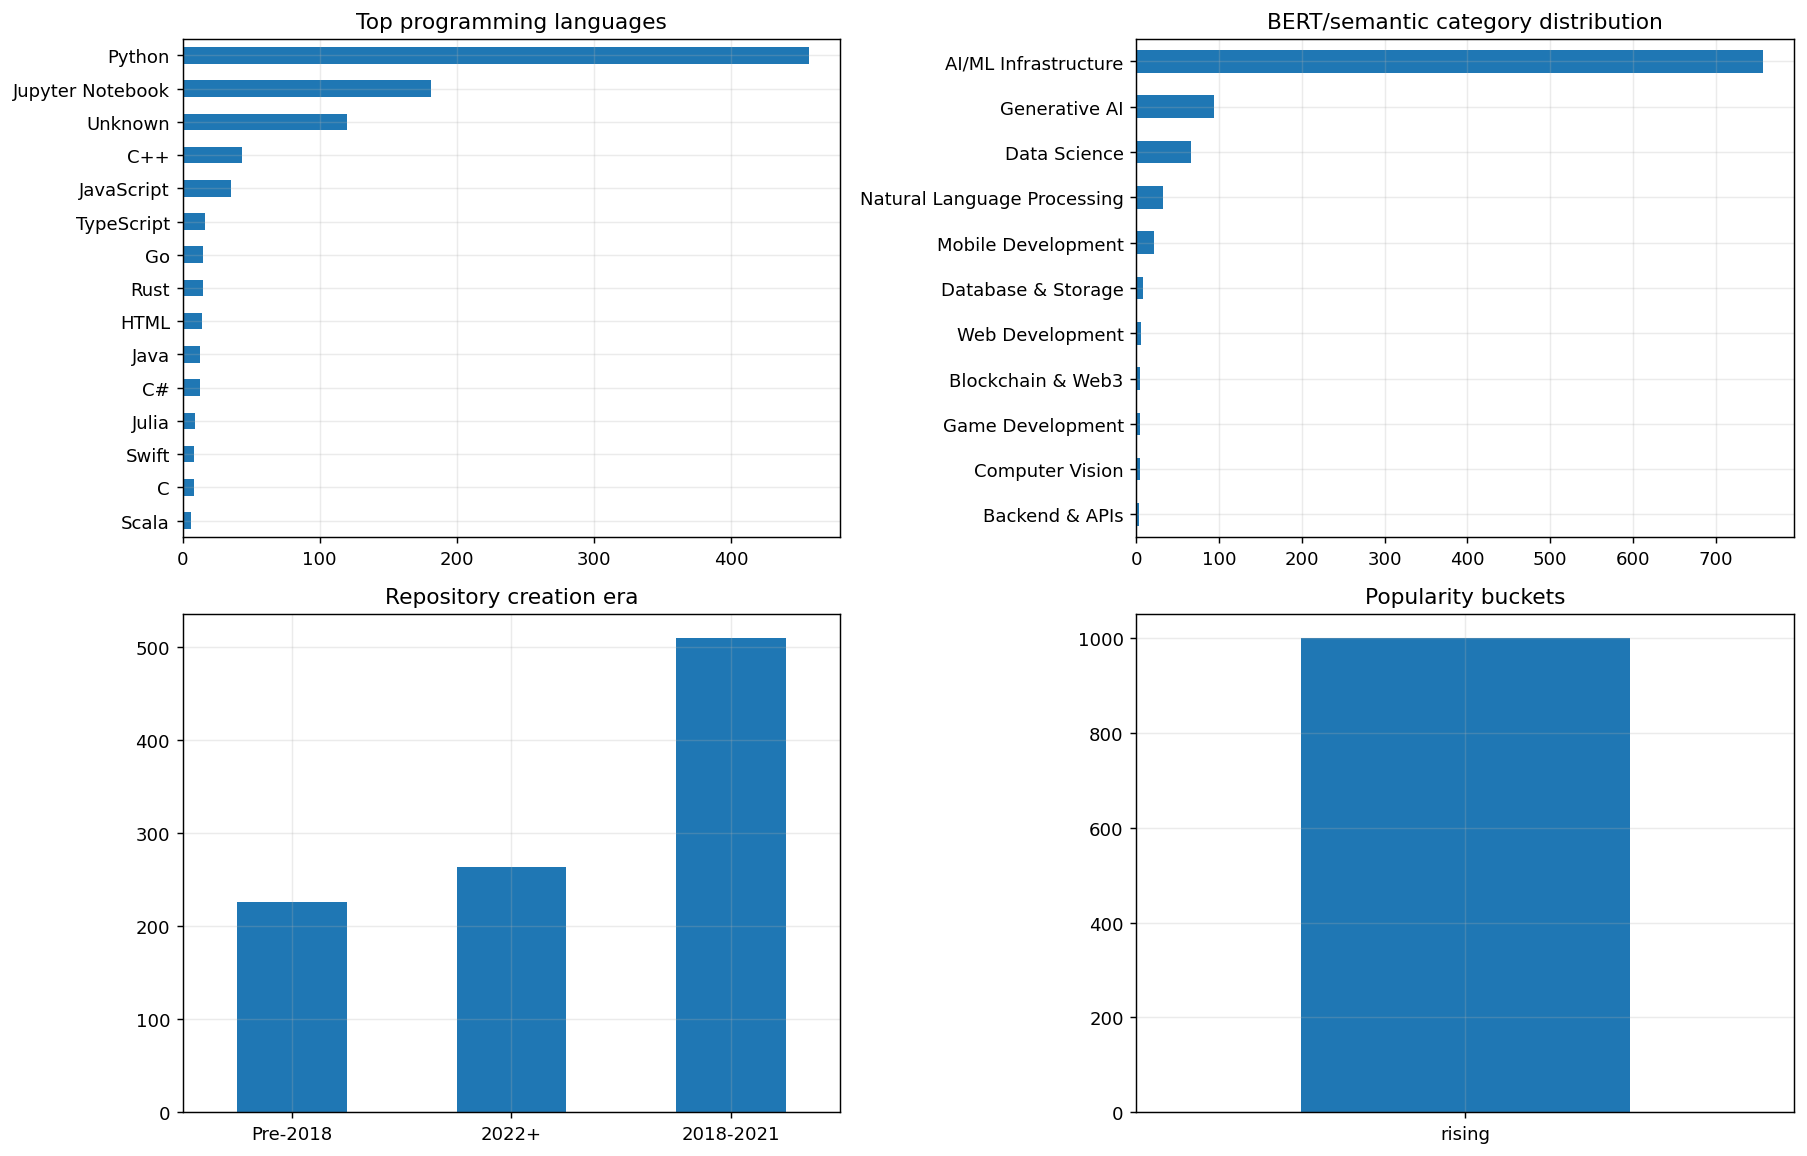

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pd.Series(stats["language_distribution"]).head(15).sort_values().plot(
    kind="barh", ax=axes[0, 0], title="Top programming languages"
)
pd.Series(stats["category_distribution"]).sort_values().plot(
    kind="barh", ax=axes[0, 1], title="BERT/semantic category distribution"
)
pd.Series(stats["era_distribution"]).plot(
    kind="bar", ax=axes[1, 0], title="Repository creation era", rot=0
)
pd.Series(stats["popularity_distribution"]).plot(
    kind="bar", ax=axes[1, 1], title="Popularity buckets", rot=0
)

plt.tight_layout()

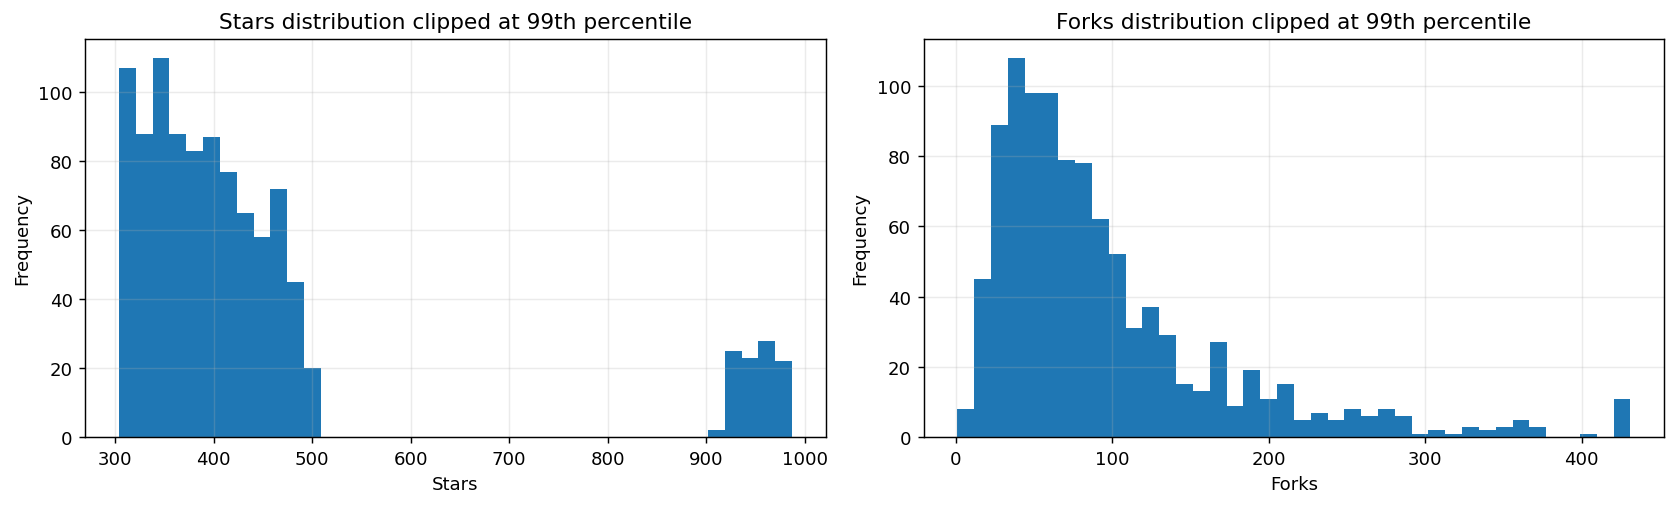

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

repos["stars"].clip(upper=repos["stars"].quantile(0.99)).plot(
    kind="hist", bins=40, ax=axes[0], title="Stars distribution clipped at 99th percentile"
)
repos["forks"].clip(upper=repos["forks"].quantile(0.99)).plot(
    kind="hist", bins=40, ax=axes[1], title="Forks distribution clipped at 99th percentile"
)

axes[0].set_xlabel("Stars")
axes[1].set_xlabel("Forks")
plt.tight_layout()

## 5.1 Data Quality and Cleaning Evidence

A strong data mining project should show that the collected data is usable. These checks measure duplicate names, valid technology stacks, valid numeric values, and text coverage.

In [17]:
quality_metrics = {
    "duplicate_repository_names": int(repos["name"].duplicated().sum()),
    "missing_descriptions": int((repos["description"].fillna("").str.len() == 0).sum()),
    "empty_tech_stacks": int(repos["tech_stack"].apply(lambda x: len(x) if isinstance(x, list) else 0).eq(0).sum()),
    "negative_stars": int((repos["stars"] < 0).sum()),
    "negative_forks": int((repos["forks"] < 0).sum()),
    "invalid_confidence": int(((repos["bert_confidence"] < 0) | (repos["bert_confidence"] > 1)).sum()),
    "unique_languages": int(repos["language"].nunique()),
    "unique_categories": int(repos["bert_category"].nunique()),
}

quality_df = pd.DataFrame(
    [{"metric": key, "value": value} for key, value in quality_metrics.items()]
)
display(quality_df)

assert quality_metrics["duplicate_repository_names"] == 0
assert quality_metrics["empty_tech_stacks"] == 0
assert quality_metrics["negative_stars"] == 0
assert quality_metrics["negative_forks"] == 0
assert quality_metrics["invalid_confidence"] == 0
print("Data quality checks passed.")

,metric,value
0,duplicate_repository_names,0
1,missing_descriptions,5
2,empty_tech_stacks,0
3,negative_stars,0
4,negative_forks,0
5,invalid_confidence,0
6,unique_languages,42
7,unique_categories,11


Data quality checks passed.


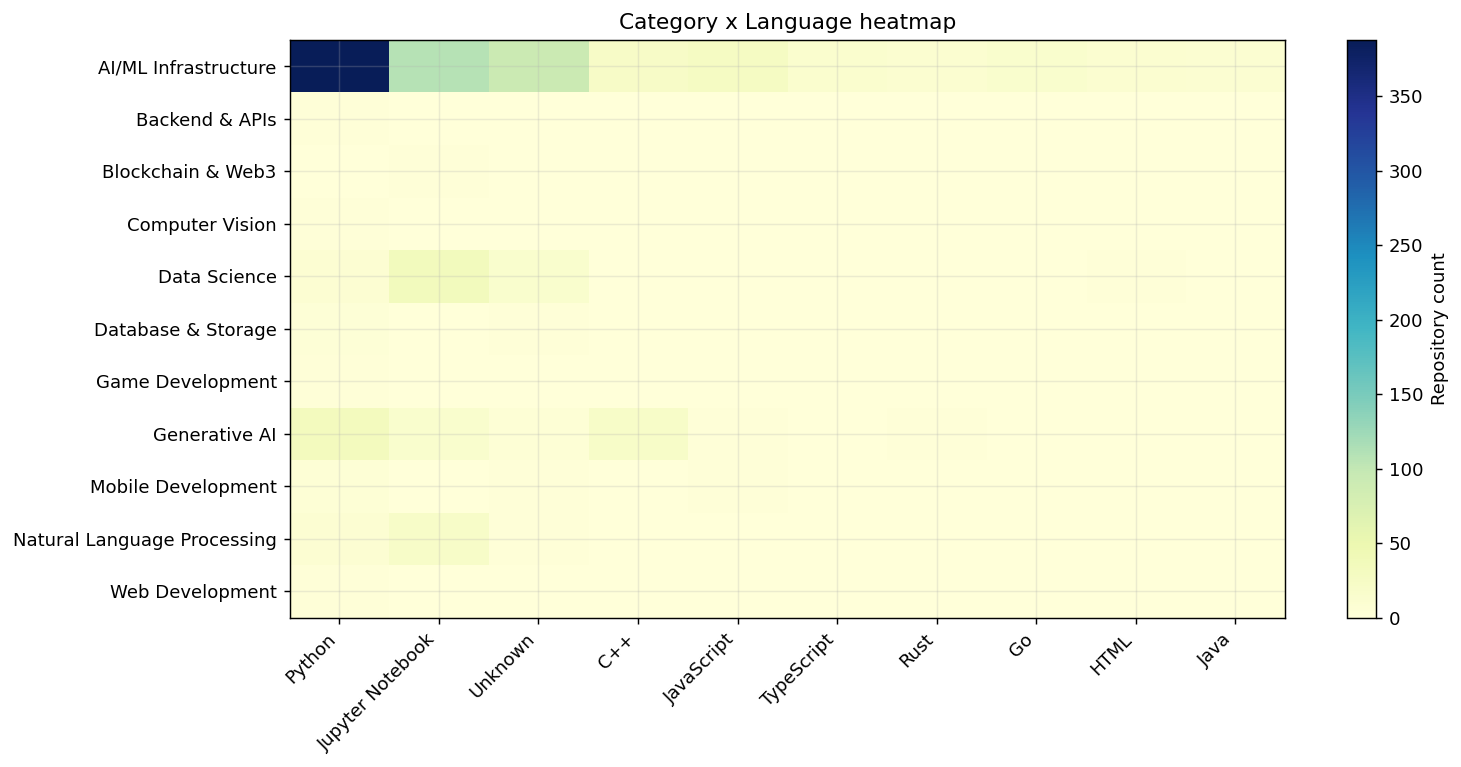

In [18]:
category_language = pd.crosstab(repos["bert_category"], repos["language"])
top_langs = repos["language"].value_counts().head(10).index
heatmap_data = category_language[top_langs]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(top_langs)))
ax.set_xticklabels(top_langs, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("Category x Language heatmap")
plt.colorbar(im, ax=ax, label="Repository count")
plt.tight_layout()

## 6. Data Preprocessing

Preprocessing converts raw GitHub metadata into mining-ready features:

1. Clean description and README text.
2. Normalize topic aliases such as `ml` to `machine-learning`.
3. Remove weak generic tags such as `tool`, `framework`, and `awesome`.
4. Merge topics with programming language to form a transaction-style `tech_stack`.
5. Create year, era, popularity, and semantic text features.

The production implementation is in `scripts/run_pipeline.py`.

In [19]:
STOPWORDS = {
    "awesome", "list", "tool", "tools", "resource", "resources",
    "tutorial", "book", "course", "open-source", "hacktoberfest",
    "cli", "api", "sdk", "library", "framework", "platform",
    "cloud-native", "serverless", "real-time", "high-performance",
    "scalable", "production-ready", "enterprise"
}

ALIASES = {
    "ai": "artificial-intelligence",
    "ml": "machine-learning",
    "dl": "deep-learning",
    "nlp": "natural-language-processing",
    "cv": "computer-vision",
    "llm": "large-language-model",
    "genai": "generative-ai",
    "js": "javascript",
    "ts": "typescript",
    "k8s": "kubernetes",
}

def clean_text(value, limit=None):
    text = "" if value is None else str(value)
    text = re.sub(r"```[\s\S]*?```", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s\+\-\#\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text[:limit] if limit else text

def normalize_topic(topic):
    value = str(topic or "").lower().strip().replace("_", "-")
    value = re.sub(r"\s+", "-", value)
    return ALIASES.get(value, value)

def normalize_topics(topics):
    output = []
    for topic in topics if isinstance(topics, list) else []:
        topic = normalize_topic(topic)
        if topic and topic not in STOPWORDS and len(topic) > 2:
            output.append(topic)
    return sorted(set(output))

print(clean_text("Fast <b>React</b> framework for AI apps! https://example.com"))
print(normalize_topics(["ML", "awesome", "k8s", "React Native"]))

fast react framework for ai apps
['kubernetes', 'machine-learning', 'react-native']


In [20]:
display(repos[["name", "language", "topics", "tech_stack", "era", "popularity"]].sample(10, random_state=7))

,name,language,topics,tech_stack,era,popularity
778,anish-lakkapragada/SeaLion,Python,"[algorithms, batch-normalization, data-analysis, data-science, dbscan-clustering, k-ne...","[algorithms, batch-normalization, data-analysis, data-science, dbscan-clustering, k-ne...",2018-2021,rising
334,Mr-Homeless/waldo,Python,"[artificial-intelligence, cheat-detection, computer-vision, deep-learning, gaming, mac...","[artificial-intelligence, cheat-detection, computer-vision, deep-learning, gaming, mac...",2022+,rising
271,turing-machines/mentals-ai,C++,"[ai-agents, artificial-intelligence, gpt, gpt-4o, large-language-model, llama3, machin...","[ai-agents, artificial-intelligence, c++, gpt, gpt-4o, large-language-model, llama3, m...",2022+,rising
802,Kaleidophon/deep-significance,Python,"[compare-scores, deep-learning, deep-neural-networks, deeplearning, hypothesis-testing...","[compare-scores, deep-learning, deep-neural-networks, deeplearning, hypothesis-testing...",2018-2021,rising
216,RLE-Foundation/RLeXplore,Jupyter Notebook,"[baselines, efficient-algorithm, exploration-strategy, gym, machine-learning, pybullet...","[baselines, efficient-algorithm, exploration-strategy, gym, jupyter notebook, machine-...",2022+,rising
408,HazyResearch/fonduer,Python,"[knowledge-base-construction, machine-learning, multimodality]","[knowledge-base-construction, machine-learning, multimodality, python]",2018-2021,rising
812,unionai-oss/unionml,Python,"[machine-learning, mlops]","[machine-learning, mlops, python]",2018-2021,rising
94,SarvagyaVaish/FlappyBirdRL,JavaScript,"[flappy-bird, machine-learning, reinforcement-learning]","[flappy-bird, javascript, machine-learning, reinforcement-learning]",Pre-2018,rising
487,ilastik/ilastik,Python,"[ilastik, machine-learning, python]","[ilastik, machine-learning, python]",Pre-2018,rising
170,cbovar/ConvNetSharp,C#,"[artificial-intelligence, convolution, csharp, machine-learning, neural-network]","[artificial-intelligence, c#, convolution, csharp, machine-learning, neural-network]",Pre-2018,rising


## 7. Technology Transaction Dataset

For association rule mining, every repository is treated as one transaction:

`transaction(repo) = normalized_topics(repo) union {primary_language(repo)}`

This lets us discover technology stacks that frequently appear together.

Total transactions: 1,000
Average items per transaction: 8.35


,technology,count,support
0,machine-learning,959,0.959
1,python,486,0.486
2,deep-learning,400,0.400
3,artificial-intelligence,195,0.195
4,jupyter notebook,177,0.177
5,data-science,143,0.143
6,pytorch,118,0.118
7,computer-vision,99,0.099
8,natural-language-processing,83,0.083
9,neural-network,71,0.071


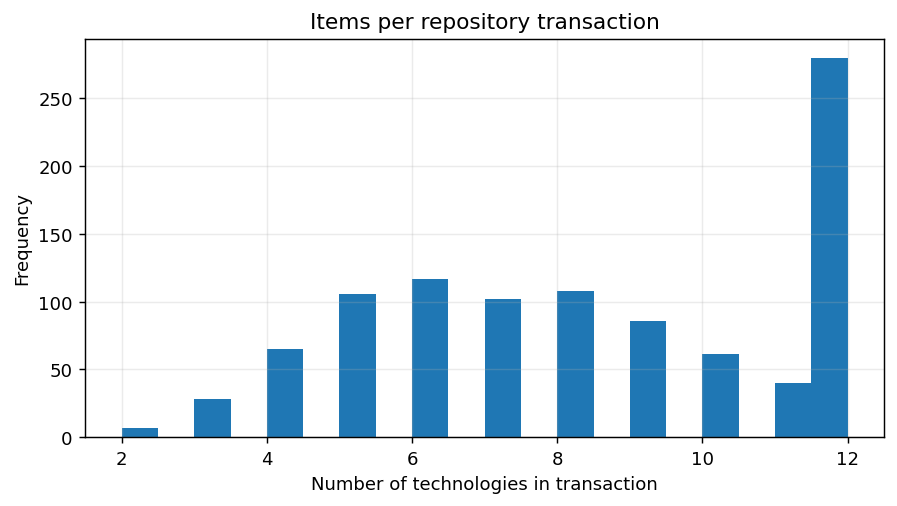

In [21]:
transactions = repos["tech_stack"].apply(lambda x: x if isinstance(x, list) else []).tolist()
transaction_lengths = pd.Series([len(t) for t in transactions])

print(f"Total transactions: {len(transactions):,}")
print(f"Average items per transaction: {transaction_lengths.mean():.2f}")

item_counts = Counter(item for tx in transactions for item in tx)
top_items = pd.DataFrame(item_counts.most_common(20), columns=["technology", "count"])
top_items["support"] = top_items["count"] / len(transactions)
display(top_items)

transaction_lengths.plot(kind="hist", bins=20, title="Items per repository transaction", figsize=(7, 4))
plt.xlabel("Number of technologies in transaction")
plt.tight_layout()

## 8. Association Rule Mining - Apriori

For a rule `A -> B`:

- Support = count(A union B) / N
- Confidence = support(A union B) / support(A)
- Lift = confidence(A -> B) / support(B)
- Conviction measures implication strength
- Leverage measures how much more often A and B occur together than expected by independence

The exported rules are mined by the pipeline and sorted by lift, confidence, and support count.

In [22]:
display(rules[[
    "antecedent", "consequent", "support", "support_count",
    "confidence", "lift", "conviction", "leverage"
]].head(20))

display(pd.Series(stats["frequent_itemsets"], name="count"))

,antecedent,consequent,support,support_count,confidence,lift,conviction,leverage
0,[deep-reinforcement-learning],[reinforcement-learning],0.013,13,0.92857,18.57143,13.30000,0.01230
1,[deep-reinforcement-learning],"[machine-learning, reinforcement-learning]",0.013,13,0.92857,18.57143,13.30000,0.01230
2,"[deep-reinforcement-learning, machine-learning]",[reinforcement-learning],0.013,13,0.92857,18.57143,13.30000,0.01230
3,[reinforcement-learning],[deep-reinforcement-learning],0.013,13,0.26000,18.57143,1.33243,0.01230
4,[reinforcement-learning],"[deep-reinforcement-learning, machine-learning]",0.013,13,0.26000,18.57143,1.33243,0.01230
5,"[machine-learning, reinforcement-learning]",[deep-reinforcement-learning],0.013,13,0.26000,18.57143,1.33243,0.01230
6,[image-processing],"[computer-vision, python]",0.013,13,0.54167,9.84848,2.06182,0.01168
7,[keras],"[deep-learning, tensorflow]",0.018,18,0.62069,9.26402,2.45973,0.01606
8,"[deep-learning, tensorflow]",[keras],0.018,18,0.26866,9.26402,1.32769,0.01606
9,"[keras, python]",[tensorflow],0.015,15,0.78947,8.39866,4.30350,0.01321


frequent_1_itemsets     73
frequent_2_itemsets    165
frequent_3_itemsets    140
min_support_count       12
Name: count, dtype: int64

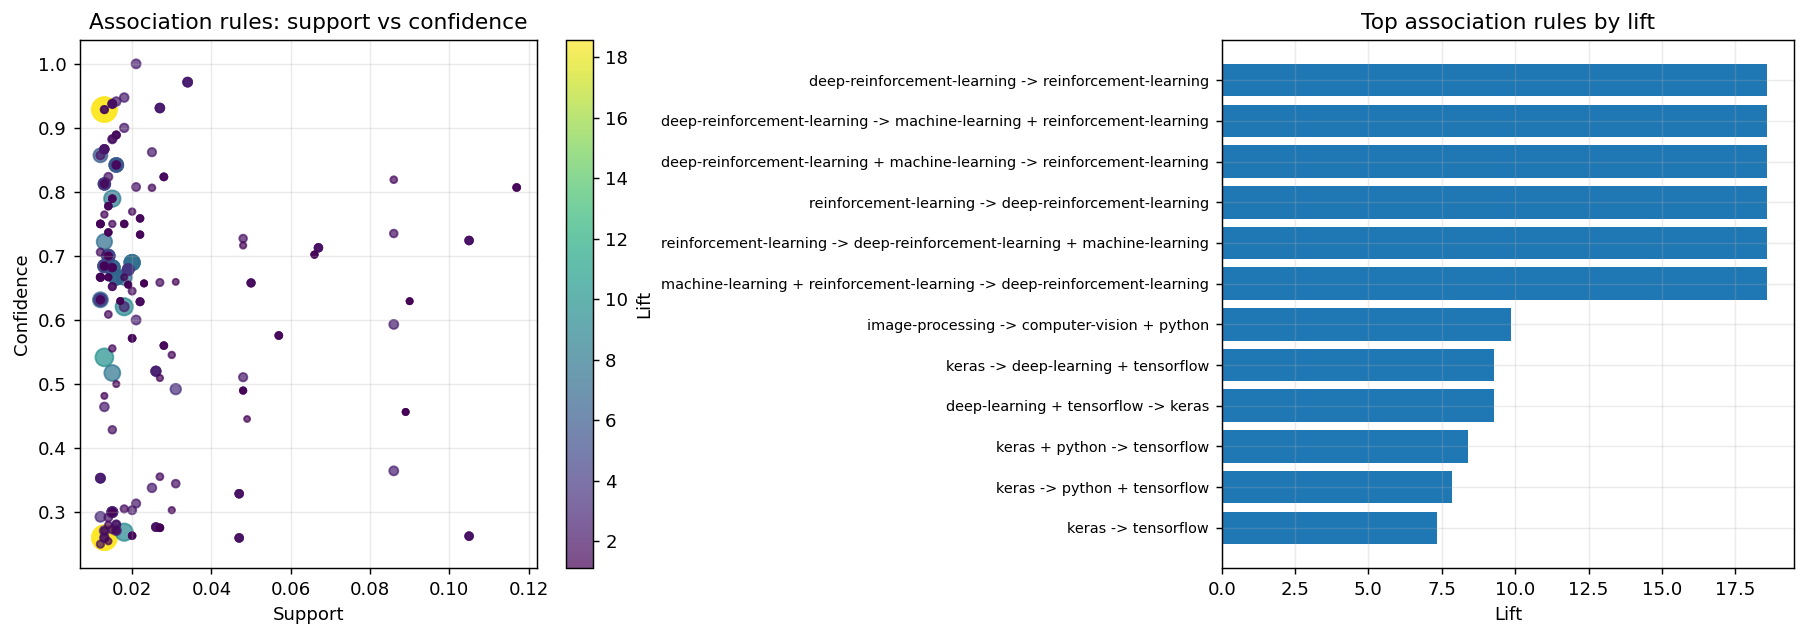

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(
    rules["support"], rules["confidence"],
    s=rules["lift"].clip(upper=25) * 10,
    c=rules["lift"], cmap="viridis", alpha=0.7
)
axes[0].set_title("Association rules: support vs confidence")
axes[0].set_xlabel("Support")
axes[0].set_ylabel("Confidence")
plt.colorbar(scatter, ax=axes[0], label="Lift")

top_rule_labels = (
    rules.head(12)["antecedent"].apply(lambda x: " + ".join(x))
    + " -> "
    + rules.head(12)["consequent"].apply(lambda x: " + ".join(x))
)
axes[1].barh(range(len(top_rule_labels)), rules.head(12)["lift"])
axes[1].set_yticks(range(len(top_rule_labels)))
axes[1].set_yticklabels(top_rule_labels, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Top association rules by lift")
axes[1].set_xlabel("Lift")

plt.tight_layout()

## 8.1 Rule Quality Interpretation

High lift alone is not enough. A useful rule should also have enough support count to matter. The table below groups rules into practical decision-support tiers.

In [24]:
def rule_tier(row):
    if row["lift"] >= 10 and row["confidence"] >= 0.8 and row["support_count"] >= stats["frequent_itemsets"]["min_support_count"]:
        return "strong stack signal"
    if row["lift"] >= 3 and row["confidence"] >= 0.5:
        return "useful recommendation"
    return "exploratory"

rules = rules.copy()
rules["tier"] = rules.apply(rule_tier, axis=1)
display(rules["tier"].value_counts().rename_axis("tier").reset_index(name="rules"))

display(rules[[
    "antecedent", "consequent", "support_count", "confidence", "lift", "tier"
]].head(25))

,tier,rules
0,exploratory,227
1,useful recommendation,35
2,strong stack signal,3


,antecedent,consequent,support_count,confidence,lift,tier
0,[deep-reinforcement-learning],[reinforcement-learning],13,0.92857,18.57143,strong stack signal
1,[deep-reinforcement-learning],"[machine-learning, reinforcement-learning]",13,0.92857,18.57143,strong stack signal
2,"[deep-reinforcement-learning, machine-learning]",[reinforcement-learning],13,0.92857,18.57143,strong stack signal
3,[reinforcement-learning],[deep-reinforcement-learning],13,0.26000,18.57143,exploratory
4,[reinforcement-learning],"[deep-reinforcement-learning, machine-learning]",13,0.26000,18.57143,exploratory
5,"[machine-learning, reinforcement-learning]",[deep-reinforcement-learning],13,0.26000,18.57143,exploratory
6,[image-processing],"[computer-vision, python]",13,0.54167,9.84848,useful recommendation
7,[keras],"[deep-learning, tensorflow]",18,0.62069,9.26402,useful recommendation
8,"[deep-learning, tensorflow]",[keras],18,0.26866,9.26402,exploratory
9,"[keras, python]",[tensorflow],15,0.78947,8.39866,useful recommendation


,rule,support_count,confidence,lift,tier
0,deep-reinforcement-learning -> reinforcement-learning,13,0.92857,18.57143,strong stack signal
1,deep-reinforcement-learning -> machine-learning + reinforcement-learning,13,0.92857,18.57143,strong stack signal
2,deep-reinforcement-learning + machine-learning -> reinforcement-learning,13,0.92857,18.57143,strong stack signal


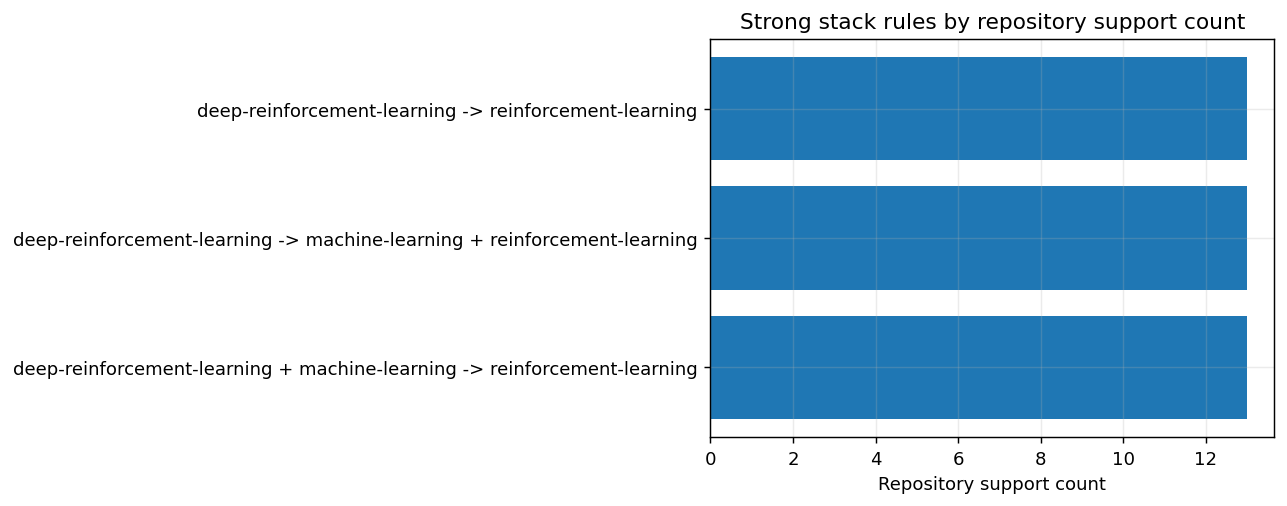

In [25]:
def format_rule_side(value):
    if isinstance(value, (list, tuple, set)):
        return " + ".join(map(str, value))
    if pd.isna(value):
        return ""
    return str(value)

if "tier" not in rules.columns:
    rules = rules.copy()
    rules["tier"] = rules.apply(rule_tier, axis=1)

plot_candidates = rules[rules["tier"] == "strong stack signal"].copy()
plot_title = "Strong stack rules by repository support count"

if plot_candidates.empty:
    plot_candidates = rules[rules["tier"] == "useful recommendation"].copy()
    plot_title = "Useful stack recommendations by repository support count"

if plot_candidates.empty:
    plot_candidates = rules.copy()
    plot_title = "Top association rules by repository support count"

top_stack_rules = (
    plot_candidates
    .sort_values(["support_count", "lift", "confidence"], ascending=False)
    .head(15)
    .copy()
)
top_stack_rules["rule"] = (
    top_stack_rules["antecedent"].apply(format_rule_side)
    + " -> "
    + top_stack_rules["consequent"].apply(format_rule_side)
)

display(top_stack_rules[["rule", "support_count", "confidence", "lift", "tier"]])

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(top_stack_rules))))
if top_stack_rules.empty:
    ax.text(0.5, 0.5, "No association rules available to plot", ha="center", va="center")
    ax.set_axis_off()
else:
    plot_df = top_stack_rules.iloc[::-1]
    ax.barh(plot_df["rule"], plot_df["support_count"])
    ax.set_title(plot_title)
    ax.set_xlabel("Repository support count")
    ax.set_ylabel("")
plt.tight_layout()

In [26]:
def recommend_stack(seed_terms, rules_df, top_n=10):
    seed = set(seed_terms)
    candidates = []
    for _, row in rules_df.iterrows():
        antecedent = set(row["antecedent"])
        consequent = set(row["consequent"])
        if seed.issubset(antecedent):
            candidates.append({
                "given": " + ".join(row["antecedent"]),
                "recommend": " + ".join(row["consequent"]),
                "support_count": row.get("support_count", 0),
                "confidence": row["confidence"],
                "lift": row["lift"],
            })
    if not candidates:
        return pd.DataFrame(columns=["given", "recommend", "support_count", "confidence", "lift"])
    return pd.DataFrame(candidates).sort_values(["lift", "confidence"], ascending=False).head(top_n)

seed_a = rules.iloc[0]["antecedent"][:1]
seed_b = rules.iloc[min(10, len(rules) - 1)]["antecedent"][:1]

print("Seed stack:", seed_a)
display(recommend_stack(seed_a, rules))

print("Seed stack:", seed_b)
display(recommend_stack(seed_b, rules))

Seed stack: ['deep-reinforcement-learning']


,given,recommend,support_count,confidence,lift
0,deep-reinforcement-learning,reinforcement-learning,13,0.92857,18.57143
1,deep-reinforcement-learning,machine-learning + reinforcement-learning,13,0.92857,18.57143
2,deep-reinforcement-learning + machine-learning,reinforcement-learning,13,0.92857,18.57143


Seed stack: ['keras']


,given,recommend,support_count,confidence,lift
0,keras,deep-learning + tensorflow,18,0.62069,9.26402
1,keras + python,tensorflow,15,0.78947,8.39866
2,keras,python + tensorflow,15,0.51724,7.83699
3,keras,tensorflow,20,0.68966,7.33676
4,keras,machine-learning + tensorflow,20,0.68966,7.33676
5,keras + machine-learning,tensorflow,20,0.68966,7.33676
6,deep-learning + keras,tensorflow,18,0.66667,7.09220
7,keras,deep-learning + python,18,0.62069,2.63004
8,keras + python,deep-learning,18,0.94737,2.36842
9,keras,deep-learning,27,0.93103,2.32759


### Optional FP-Growth Comparison

Apriori is implemented in the pipeline because it is clear and easy to explain. FP-Growth is an alternative that can be faster for very large transaction datasets. The cell below uses `mlxtend` when it is installed, and otherwise falls back to a local FP-Growth implementation so the comparison still runs in offline environments.

In [27]:
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None


def add_header_link(header, item, node):
    current = header[item][1]
    if current is None:
        header[item][1] = node
        return
    while current.link is not None:
        current = current.link
    current.link = node


def insert_fp_items(items, node, header, count):
    if not items:
        return
    first = items[0]
    child = node.children.get(first)
    if child is None:
        child = FPNode(first, count, node)
        node.children[first] = child
        add_header_link(header, first, child)
    else:
        child.count += count
    insert_fp_items(items[1:], child, header, count)


def build_fp_tree(weighted_transactions, min_count):
    item_counts = Counter()
    for tx, count in weighted_transactions:
        item_counts.update({item: count for item in set(tx)})

    frequent_counts = {
        item: count
        for item, count in item_counts.items()
        if count >= min_count
    }
    if not frequent_counts:
        return None, {}

    header = {item: [count, None] for item, count in frequent_counts.items()}
    root = FPNode(None, 0, None)

    for tx, count in weighted_transactions:
        ordered = [item for item in tx if item in frequent_counts]
        ordered.sort(key=lambda item: (-frequent_counts[item], item))
        insert_fp_items(ordered, root, header, count)

    return root, header


def prefix_path(node):
    path = []
    parent = node.parent
    while parent is not None and parent.item is not None:
        path.append(parent.item)
        parent = parent.parent
    return path


def conditional_patterns(header_entry):
    patterns = []
    node = header_entry[1]
    while node is not None:
        path = prefix_path(node)
        if path:
            patterns.append((path, node.count))
        node = node.link
    return patterns


def mine_fp_tree(header, min_count, suffix, frequent_itemsets):
    for item, (support_count, node) in sorted(header.items(), key=lambda pair: (pair[1][0], pair[0])):
        itemset = tuple(sorted((item, *suffix)))
        frequent_itemsets[itemset] = max(frequent_itemsets.get(itemset, 0), support_count)
        _, conditional_header = build_fp_tree(conditional_patterns((support_count, node)), min_count)
        if conditional_header:
            mine_fp_tree(conditional_header, min_count, (item, *suffix), frequent_itemsets)


def local_fpgrowth(sample_transactions, min_support=0.02):
    clean_transactions = [
        tuple(sorted(set(tx)))
        for tx in sample_transactions
        if tx
    ]
    transaction_count = len(clean_transactions)
    if transaction_count == 0:
        return pd.DataFrame(columns=["support", "support_count", "itemsets"])

    min_count = max(1, math.ceil(min_support * transaction_count))
    weighted_transactions = [(tx, 1) for tx in clean_transactions]
    _, header = build_fp_tree(weighted_transactions, min_count)
    frequent_itemsets = {}
    if header:
        mine_fp_tree(header, min_count, tuple(), frequent_itemsets)

    fp_df = pd.DataFrame([
        {
            "support": support_count / transaction_count,
            "support_count": support_count,
            "itemsets": frozenset(itemset),
        }
        for itemset, support_count in frequent_itemsets.items()
    ])
    if fp_df.empty:
        return pd.DataFrame(columns=["support", "support_count", "itemsets"])
    return fp_df.sort_values(["support", "support_count"], ascending=False).reset_index(drop=True)


sample_transactions = transactions[:5000]
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth

    encoder = TransactionEncoder()
    one_hot = encoder.fit(sample_transactions).transform(sample_transactions)
    tx_df = pd.DataFrame(one_hot, columns=encoder.columns_)
    fp = fpgrowth(tx_df, min_support=0.02, use_colnames=True).sort_values("support", ascending=False)
    fp["support_count"] = (fp["support"] * len(sample_transactions)).round().astype(int)
    fp = fp[["support", "support_count", "itemsets"]]
    print("FP-Growth comparison method: mlxtend")
except ModuleNotFoundError:
    print("FP-Growth comparison method: local fallback")
    fp = local_fpgrowth(sample_transactions, min_support=0.02)
except Exception as exc:
    print("FP-Growth comparison method: local fallback")
    print(f"mlxtend path failed with {type(exc).__name__}; using local implementation.")
    fp = local_fpgrowth(sample_transactions, min_support=0.02)

print(f"Frequent itemsets discovered: {len(fp):,}")
display(fp.head(15))

FP-Growth comparison method: local fallback
Frequent itemsets discovered: 123


,support,support_count,itemsets
0,0.959,959,(machine-learning)
1,0.486,486,(python)
2,0.486,486,"(python, machine-learning)"
3,0.400,400,(deep-learning)
4,0.381,381,"(machine-learning, deep-learning)"
5,0.195,195,(artificial-intelligence)
6,0.194,194,"(python, deep-learning)"
7,0.194,194,"(python, machine-learning, deep-learning)"
8,0.185,185,"(machine-learning, artificial-intelligence)"
9,0.177,177,(jupyter notebook)


## 9. Graph Construction

The project uses graph mining in two ways:

1. Technology co-occurrence graph: nodes are technologies/topics/languages, weighted edges mean the technologies appear in the same repositories.
2. Repository similarity graph: nodes are repositories, weighted edges mean repositories share technologies.

The dashboard uses the technology graph because it is readable and directly supports technology trend decisions. The repository graph below is included to satisfy the influential repository interpretation of the task.

In [28]:
display(nodes[["id", "pagerank", "authority", "hub", "community", "tribe", "count"]].head(20))
display(edges.head(10))

,id,pagerank,authority,hub,community,tribe,count
0,machine-learning,0.072508,0.583367,0.583367,2,Machine-Learning Stack,1000
1,python,0.042287,0.489150,0.489150,2,Machine-Learning Stack,563
2,deep-learning,0.030836,0.408021,0.408021,2,Machine-Learning Stack,400
3,artificial-intelligence,0.015245,0.214723,0.214723,2,Machine-Learning Stack,195
4,jupyter notebook,0.012106,0.180507,0.180507,2,Machine-Learning Stack,181
5,data-science,0.012001,0.165961,0.165961,2,Machine-Learning Stack,143
6,pytorch,0.011529,0.190751,0.190751,2,Machine-Learning Stack,145
7,computer-vision,0.008057,0.117013,0.117013,2,Machine-Learning Stack,99
8,natural-language-processing,0.008052,0.112677,0.112677,2,Machine-Learning Stack,98
9,tensorflow,0.007627,0.122456,0.122456,2,Machine-Learning Stack,94


,source,target,weight
0,machine-learning,python,563
1,deep-learning,machine-learning,400
2,deep-learning,python,236
3,artificial-intelligence,machine-learning,195
4,jupyter notebook,machine-learning,181
5,machine-learning,pytorch,145
6,data-science,machine-learning,143
7,python,pytorch,117
8,artificial-intelligence,python,110
9,deep-learning,pytorch,105


## 9.1 Strongest Technology Relationships

The highest-weight edges reveal technologies that repeatedly occur in the same repositories. These relationships are useful for stack suggestions and ecosystem understanding.

,relationship,weight
0,machine-learning + python,563
1,deep-learning + machine-learning,400
2,deep-learning + python,236
3,artificial-intelligence + machine-learning,195
4,jupyter notebook + machine-learning,181
5,machine-learning + pytorch,145
6,data-science + machine-learning,143
7,python + pytorch,117
8,artificial-intelligence + python,110
9,deep-learning + pytorch,105


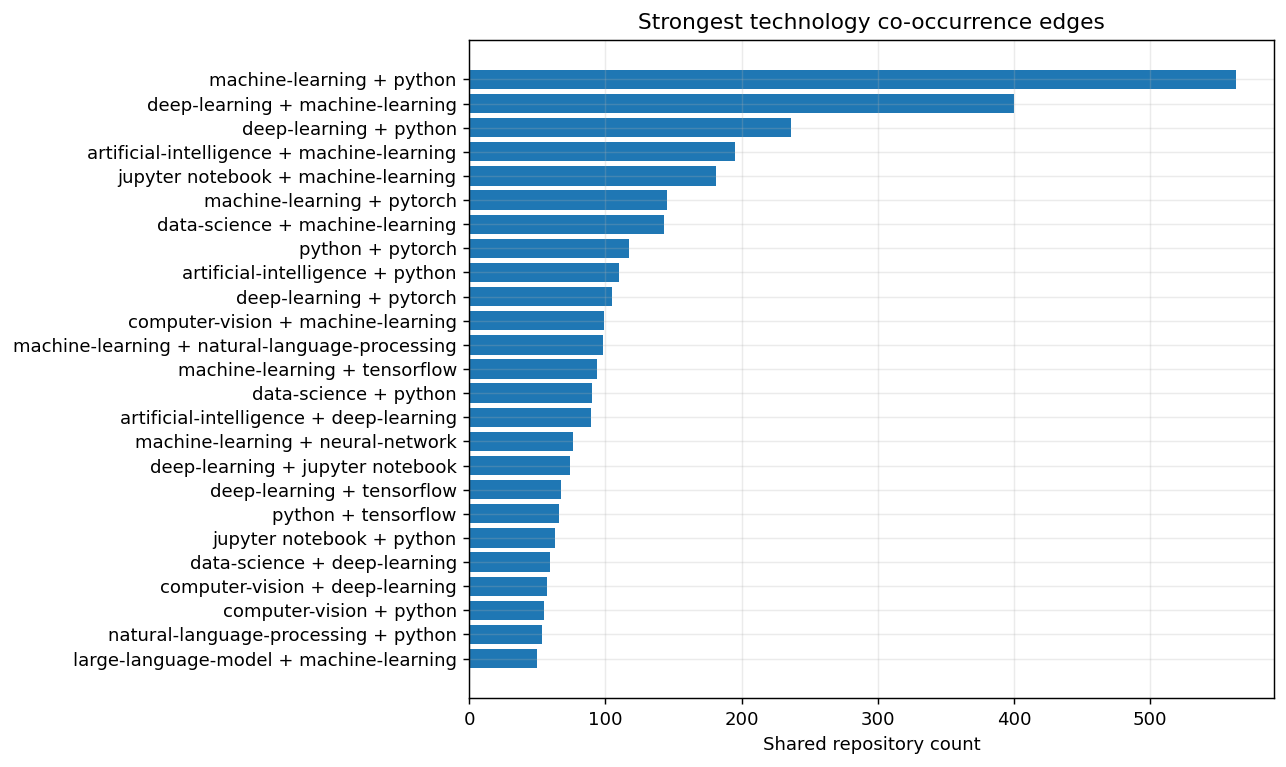

In [29]:
top_edges = edges.sort_values("weight", ascending=False).head(25).copy()
top_edges["relationship"] = top_edges["source"] + " + " + top_edges["target"]
display(top_edges[["relationship", "weight"]])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_edges["relationship"].iloc[::-1], top_edges["weight"].iloc[::-1])
ax.set_title("Strongest technology co-occurrence edges")
ax.set_xlabel("Shared repository count")
plt.tight_layout()

In [30]:
community_summary = (
    nodes.groupby(["community", "tribe"])
    .agg(
        technologies=("id", "count"),
        total_repo_mentions=("count", "sum"),
        max_pagerank=("pagerank", "max"),
    )
    .sort_values(["total_repo_mentions", "max_pagerank"], ascending=False)
    .reset_index()
)
display(community_summary.head(20))

,community,tribe,technologies,total_repo_mentions,max_pagerank
0,2,Machine-Learning Stack,3377,9513,0.072508
1,1,Event-Notifications Stack,6,6,0.000177
2,0,Exploratory-Data-Analysis Stack,5,5,0.000161


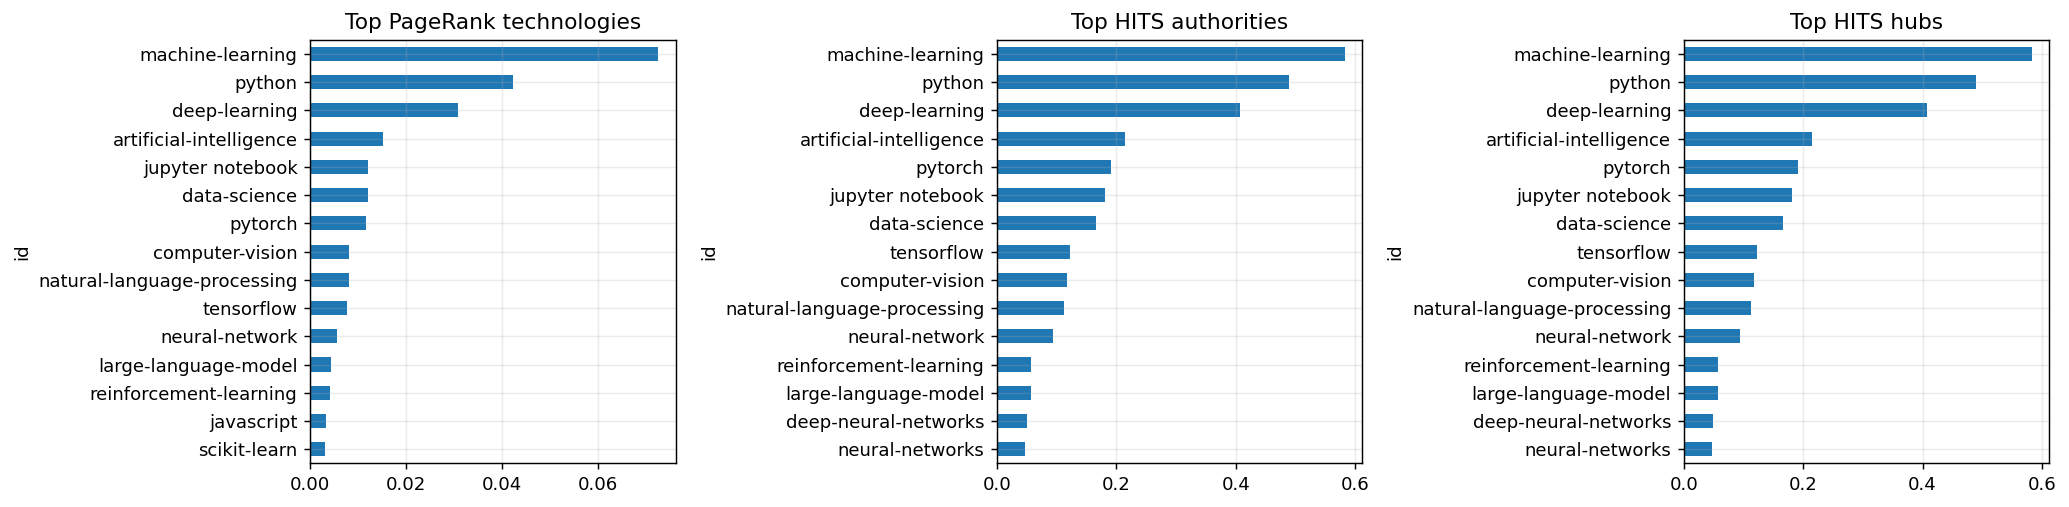

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

nodes.head(15).sort_values("pagerank").plot(
    kind="barh", x="id", y="pagerank", ax=axes[0], legend=False, title="Top PageRank technologies"
)
nodes.sort_values("authority", ascending=False).head(15).sort_values("authority").plot(
    kind="barh", x="id", y="authority", ax=axes[1], legend=False, title="Top HITS authorities"
)
nodes.sort_values("hub", ascending=False).head(15).sort_values("hub").plot(
    kind="barh", x="id", y="hub", ax=axes[2], legend=False, title="Top HITS hubs"
)

plt.tight_layout()

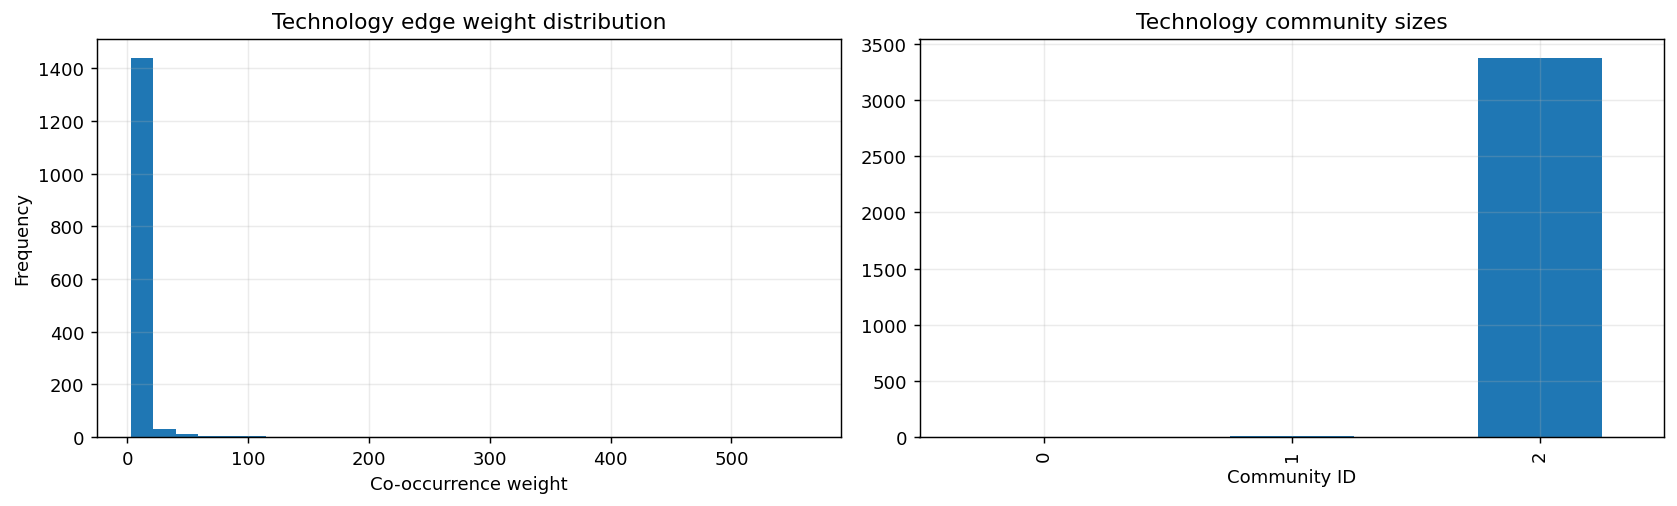

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edges["weight"].plot(kind="hist", bins=30, ax=axes[0], title="Technology edge weight distribution")
nodes["community"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Technology community sizes")
axes[0].set_xlabel("Co-occurrence weight")
axes[1].set_xlabel("Community ID")
plt.tight_layout()

## 10. Link Analysis - PageRank and HITS

PageRank ranks nodes that are connected to other important nodes. HITS separates nodes into:

- Hubs: nodes that connect to many authoritative nodes
- Authorities: nodes that are pointed to by strong hubs

For an undirected co-occurrence graph, hub and authority values can be similar, but they are still useful for ranking central ecosystem technologies.

In [33]:
def weighted_pagerank(node_count, weighted_edges, damping=0.85, iterations=60):
    adj = defaultdict(dict)
    degree = defaultdict(float)
    for src, dst, weight in weighted_edges:
        adj[src][dst] = adj[src].get(dst, 0.0) + weight
        adj[dst][src] = adj[dst].get(src, 0.0) + weight
        degree[src] += weight
        degree[dst] += weight

    ranks = np.full(node_count, 1.0 / node_count)
    for _ in range(iterations):
        new = np.full(node_count, (1 - damping) / node_count)
        dangling = ranks[[i for i in range(node_count) if degree.get(i, 0) == 0]].sum()
        new += damping * dangling / node_count
        for node in range(node_count):
            for nb, weight in adj.get(node, {}).items():
                if degree[nb]:
                    new[node] += damping * ranks[nb] * weight / degree[nb]
        ranks = new / new.sum()
    return ranks

def weighted_hits(node_count, weighted_edges, iterations=40):
    adj = defaultdict(dict)
    for src, dst, weight in weighted_edges:
        adj[src][dst] = adj[src].get(dst, 0.0) + weight
        adj[dst][src] = adj[dst].get(src, 0.0) + weight

    hubs = np.ones(node_count)
    auth = np.ones(node_count)
    for _ in range(iterations):
        auth_new = np.zeros(node_count)
        for node in range(node_count):
            auth_new[node] = sum(hubs[nb] * weight for nb, weight in adj.get(node, {}).items())
        auth = auth_new / (np.linalg.norm(auth_new) or 1)

        hubs_new = np.zeros(node_count)
        for node in range(node_count):
            hubs_new[node] = sum(auth[nb] * weight for nb, weight in adj.get(node, {}).items())
        hubs = hubs_new / (np.linalg.norm(hubs_new) or 1)
    return hubs, auth

### Repository Influence Graph

To avoid a dense graph with millions of edges, this notebook builds a repository graph on the most starred repositories and caps each technology bucket. This keeps the graph interpretable while still using shared technologies as the relationship signal.

In [34]:
top_repo_graph = repos.nlargest(2500, "stars").reset_index(drop=True)
repo_stacks = top_repo_graph["tech_stack"].apply(lambda x: x if isinstance(x, list) else []).tolist()

tech_to_repo_ids = defaultdict(list)
for idx, stack in enumerate(repo_stacks):
    for tech in stack:
        tech_to_repo_ids[tech].append(idx)

pair_counts = Counter()
for tech, ids in tech_to_repo_ids.items():
    ids = sorted(ids, key=lambda i: -top_repo_graph.loc[i, "stars"])[:250]
    for a, b in combinations(ids, 2):
        pair_counts[(a, b)] += 1

repo_weighted_edges = [
    (a, b, weight)
    for (a, b), weight in sorted(pair_counts.items(), key=lambda item: (-item[1], item[0]))[:5000]
]

repo_pr = weighted_pagerank(len(top_repo_graph), repo_weighted_edges)
repo_hub, repo_auth = weighted_hits(len(top_repo_graph), repo_weighted_edges)

repo_influence = top_repo_graph[["name", "stars", "forks", "language", "bert_category"]].copy()
repo_influence["repo_pagerank"] = repo_pr
repo_influence["repo_hub"] = repo_hub
repo_influence["repo_authority"] = repo_auth
repo_influence = repo_influence.sort_values("repo_pagerank", ascending=False)

display(repo_influence.head(20))
print(f"Repository graph nodes: {len(top_repo_graph):,}")
print(f"Repository graph edges: {len(repo_weighted_edges):,}")

,name,stars,forks,language,bert_category,repo_pagerank,repo_hub,repo_authority
120,hamelsmu/code_search,491,136,Jupyter Notebook,AI/ML Infrastructure,0.011449,0.185265,0.185265
313,zimingttkx/AI-Practices,437,67,Jupyter Notebook,AI/ML Infrastructure,0.010903,0.138343,0.138343
18,keras-team/keras-hub,978,335,Python,Web Development,0.010531,0.175341,0.175341
157,greyhatguy007/deep-learning-specialization,478,267,Jupyter Notebook,AI/ML Infrastructure,0.008465,0.141996,0.141996
193,ploomber/sklearn-evaluation,468,55,Python,AI/ML Infrastructure,0.008296,0.161216,0.161216
41,raiyanyahya/how-to-train-your-gpt,958,134,Jupyter Notebook,AI/ML Infrastructure,0.008189,0.137548,0.137548
236,dylanhogg/awesome-python,458,40,Unknown,AI/ML Infrastructure,0.007743,0.129374,0.129374
80,baal-org/baal,929,90,Python,AI/ML Infrastructure,0.007191,0.152634,0.152634
278,rohan-paul/MachineLearning-DeepLearning-Code-for-my-YouTube-Channel,445,200,Jupyter Notebook,AI/ML Infrastructure,0.007116,0.068111,0.068111
84,shenweichen/Coursera,927,660,Jupyter Notebook,AI/ML Infrastructure,0.007005,0.077081,0.077081


Repository graph nodes: 1,000
Repository graph edges: 5,000


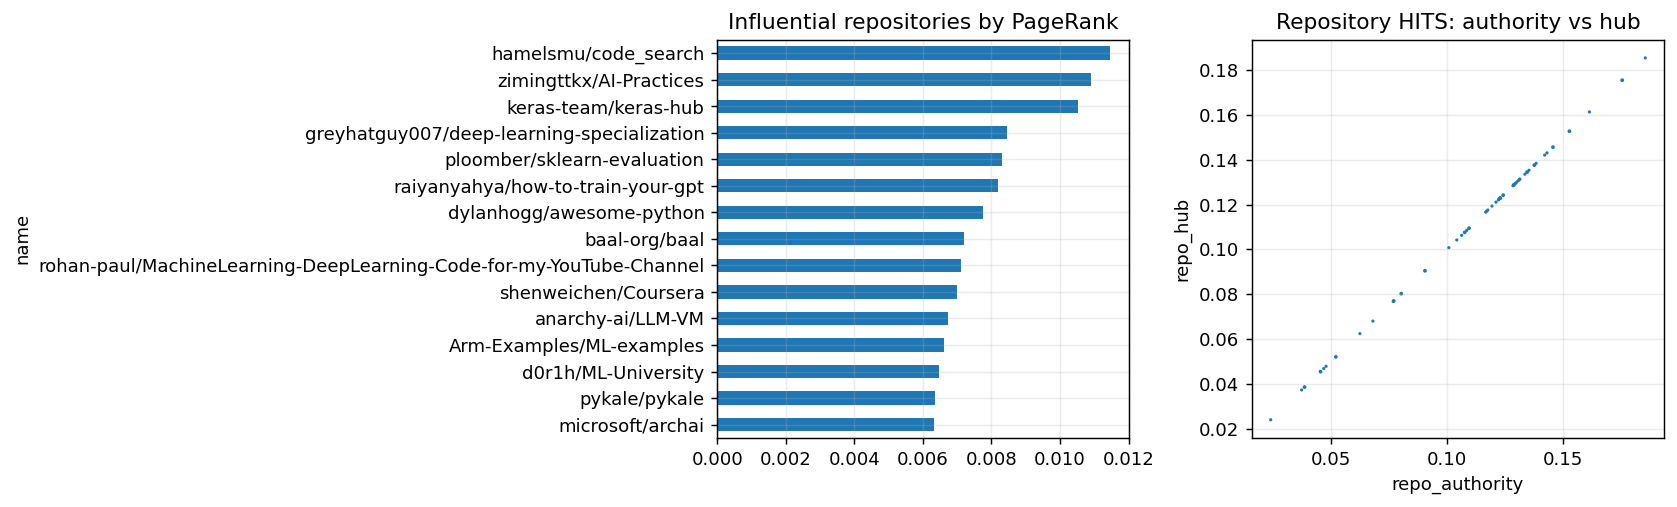

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

repo_influence.head(15).sort_values("repo_pagerank").plot(
    kind="barh", x="name", y="repo_pagerank", ax=axes[0], legend=False,
    title="Influential repositories by PageRank"
)
repo_influence.head(50).plot(
    kind="scatter", x="repo_authority", y="repo_hub",
    s=repo_influence.head(50)["stars"].clip(upper=50000) / 800,
    ax=axes[1], title="Repository HITS: authority vs hub"
)

plt.tight_layout()

## 11. BERT-based Text Classification

The pipeline uses a real pretrained BERT-Tiny model (`phob0s/bert-tiny`) to embed repository descriptions, README snippets, topics, and languages. The BERT embeddings drive category classification, clustering, and similarity recommendations. A SentenceTransformer model can still be supplied with `--semantic-model`, but the default notebook path runs real BERT without requiring PyTorch.

In [36]:
print("Semantic embedding method used by the latest pipeline run:")
print(stats["embedding_method"])

display(repos[["name", "description", "bert_category", "bert_confidence", "cluster_id"]].head(12))

Semantic embedding method used by the latest pipeline run:
BERT/NumPy BERT-Tiny: phob0s/bert-tiny


,name,description,bert_category,bert_confidence,cluster_id
0,dswah/pyGAM,[CONTRIBUTORS WELCOME] Generalized Additive Models in Python,AI/ML Infrastructure,0.5501,7
1,sematic-ai/sematic,An open-source ML pipeline development platform,Web Development,0.5519,7
2,PyPatel/Options-Trading-Strategies-in-Python,Developing Options Trading Strategies using Technical Indicators and Quantitative Methods,Generative AI,0.5537,1
3,chiphuyen/just-pandas-things,An ongoing list of pandas quirks,Blockchain & Web3,0.5501,7
4,graspologic-org/graspologic,Python package for graph statistics,Generative AI,0.5518,5
5,PAIR-code/saliency,"Framework-agnostic implementation for state-of-the-art saliency methods (XRAI, BlurIG,...",Blockchain & Web3,0.5541,7
6,Unity-Technologies/com.unity.perception,Perception toolkit for sim2real training and validation in Unity,AI/ML Infrastructure,0.5604,6
7,motional/nuplan-devkit,The devkit of the nuPlan dataset.,Database & Storage,0.5580,5
8,Mybridge/machine-learning-open-source,Monthly Series - Machine Learning Top 10 Open Source Projects,Mobile Development,0.5506,5
9,giotto-ai/giotto-tda,A high-performance topological machine learning toolbox in Python,Web Development,0.5545,7


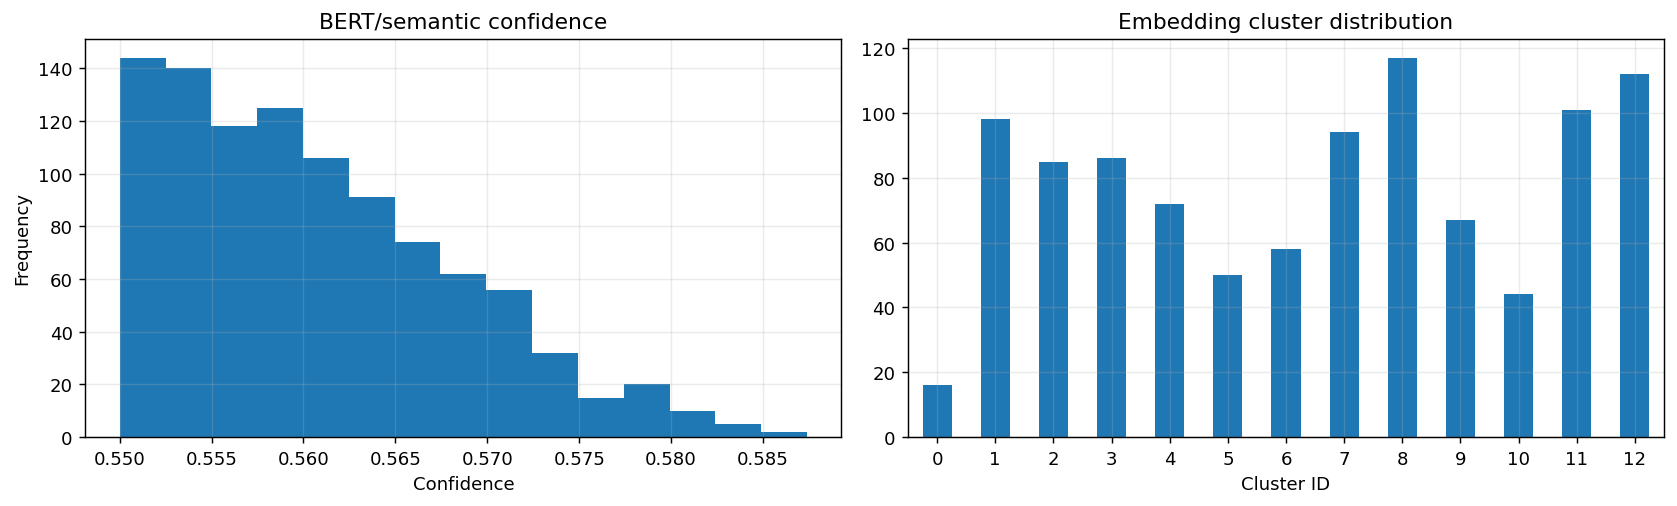

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

repos["bert_confidence"].plot(kind="hist", bins=15, ax=axes[0], title="BERT/semantic confidence")
axes[0].set_xlabel("Confidence")

pd.Series(stats["cluster_distribution"]).sort_index(key=lambda s: s.astype(int)).plot(
    kind="bar", ax=axes[1], title="Embedding cluster distribution", rot=0
)
axes[1].set_xlabel("Cluster ID")

plt.tight_layout()

In [38]:
# Real BERT-Tiny embedding demonstration using the same NumPy inference path as the pipeline.
try:
    import importlib.util

    sample_texts = (
        repos["description"].fillna("")
        + " "
        + repos["tech_stack"].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
    ).head(24).tolist()

    pipeline_path = ROOT / "scripts" / "run_pipeline.py"
    spec = importlib.util.spec_from_file_location("run_pipeline", pipeline_path)
    run_pipeline = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(run_pipeline)

    model_dir = ROOT / "models" / "bert-tiny"
    run_pipeline.ensure_bert_tiny_files(model_dir)
    model = run_pipeline.NumpyBertTiny(model_dir, max_length=96)
    sample_embeddings = model.encode(sample_texts, batch_size=12)
    print("BERT embedding sample shape:", sample_embeddings.shape)
    print("Model:", run_pipeline.BERT_TINY_REPO)
except Exception as exc:
    print("Real BERT-Tiny demo skipped in this environment:", exc)
    print("The latest processed method is:", stats["embedding_method"])

BERT embedding sample shape: (24, 128)
Model: phob0s/bert-tiny


## 11.1 Classification Evaluation When Labels Exist

The real GitHub API does not provide ground-truth topic labels. If labels are available in a future curated dataset, this section computes a sanity-check evaluation; for pure GitHub API data, it reports that no ground-truth labels are present.

In [39]:
with require_file(RAW_PATH, "raw GitHub repository data").open(encoding="utf-8") as f:
    raw_records = json.load(f)

raw_labels = pd.DataFrame([
    {"name": item.get("name"), "source_category": item.get("category")}
    for item in raw_records
    if item.get("name") and item.get("category")
])

source_to_semantic = {
    "ai_ml": "AI/ML Infrastructure",
    "web_frontend": "Web Development",
    "web_backend": "Backend & APIs",
    "data_science": "Data Science",
    "devops": "DevOps & Cloud",
    "mobile": "Mobile Development",
    "security": "Security",
    "blockchain": "Blockchain & Web3",
    "nlp": "Natural Language Processing",
    "cv": "Computer Vision",
    "genai": "Generative AI",
    "database": "Database & Storage",
    "gamedev": "Game Development",
}

if raw_labels.empty:
    print("No generator labels available. This is expected for real GitHub API data.")
else:
    eval_df = repos.merge(raw_labels, on="name", how="inner")
    eval_df["expected_category"] = eval_df["source_category"].map(source_to_semantic)
    eval_df = eval_df.dropna(subset=["expected_category"])
    eval_df["correct"] = eval_df["expected_category"].eq(eval_df["bert_category"])
    accuracy = eval_df["correct"].mean()
    print(f"Label sanity-check accuracy: {accuracy:.3f} on {len(eval_df):,} generated-label repositories")
    display(pd.crosstab(eval_df["expected_category"], eval_df["bert_category"]).head(20))

No generator labels available. This is expected for real GitHub API data.


## 12. Semantic Similarity and Recommendation

Repository recommendations are based on nearest-neighbor cosine similarity over the semantic embedding space. This supports the task requirement to recommend similar projects or technologies.

In [40]:
selected_repo = repos.iloc[0]["name"]
print("Selected repository:", selected_repo)

recommended = pd.DataFrame(
    similarities[selected_repo],
    columns=["similar_repository", "cosine_similarity"]
)
recommended = recommended.merge(
    repos[["name", "language", "bert_category", "stars"]],
    left_on="similar_repository",
    right_on="name",
    how="left"
).drop(columns=["name"])

display(recommended)

Selected repository: dswah/pyGAM


,similar_repository,cosine_similarity,language,bert_category,stars
0,sematic-ai/sematic,0.94818,Python,Web Development,999
1,HumanCompatibleAI/overcooked_ai,0.94807,Jupyter Notebook,Generative AI,969
2,machine-learning-apps/Issue-Label-Bot,0.94385,SCSS,AI/ML Infrastructure,332
3,agencyenterprise/PromptInject,0.94306,Python,AI/ML Infrastructure,490
4,microsoft/genalog,0.93938,Jupyter Notebook,AI/ML Infrastructure,355
5,keras-team/keras-hub,0.93886,Python,Web Development,978
6,qualcomm/ai-hub-apps,0.93819,Python,AI/ML Infrastructure,407
7,zetavg/LLaMA-LoRA-Tuner,0.93785,Python,Mobile Development,473


In [41]:
def show_recommendations(repo_name, top_n=8):
    if repo_name not in similarities:
        return pd.DataFrame()
    out = pd.DataFrame(similarities[repo_name][:top_n], columns=["similar_repository", "similarity"])
    return out.merge(
        repos[["name", "language", "bert_category", "stars", "description"]],
        left_on="similar_repository",
        right_on="name",
        how="left"
    ).drop(columns=["name"])

example_repo = repos.sample(1, random_state=12).iloc[0]["name"]
print("Example:", example_repo)
display(show_recommendations(example_repo))

Example: Dramwig/FlowLine


,similar_repository,similarity,language,bert_category,stars,description
0,yining1023/machine-learning-for-the-web,0.94942,JavaScript,AI/ML Infrastructure,416,"Repository for the ""Machine Learning for the Web"" class at ITP, NYU"
1,king04aman/All-In-One-Python-Projects,0.94337,Python,AI/ML Infrastructure,340,A huge collection of awesome beginner-friendly Python projects starting from very basi...
2,ml-tooling/ml-hub,0.94219,Python,AI/ML Infrastructure,319,🧰 Multi-user development platform for machine learning teams. Simple to setup within m...
3,Yarroudh/segment-lidar,0.93958,Python,AI/ML Infrastructure,364,Python package for segmenting LiDAR data using Segment-Anything Model (SAM) from Meta AI.
4,chekoduadarsh/BlocklyML,0.93904,JavaScript,AI/ML Infrastructure,473,BlocklyML is a simple visual programming Tool for python and ML. 🧩 🖥️
5,rodmarkun/SmolML,0.93766,Python,AI/ML Infrastructure,442,A fully functional and simple Machine Learning library made entirely from scratch with...
6,mikgroup/sigpy,0.93540,Python,AI/ML Infrastructure,337,"Python package for signal processing, with emphasis on iterative methods"
7,cpury/lookie-lookie,0.93529,JavaScript,AI/ML Infrastructure,374,Learning to track eye movement in the browser


## 13. Trend Analysis and Decision Support

The final objective is not only to run algorithms, but to interpret the results. The cells below identify popular technologies, strong stack combinations, and high-level recommendations.

,machine-learning,python,deep-learning,artificial-intelligence,jupyter notebook,data-science,pytorch,computer-vision,natural-language-processing,tensorflow,neural-network,large-language-model
2017,130,75.0,57.0,18.0,25.0,20.0,10.0,10.0,15.0,24.0,15.0,0.0
2018,148,79.0,66.0,21.0,32.0,19.0,18.0,13.0,12.0,21.0,19.0,0.0
2019,125,68.0,55.0,20.0,29.0,17.0,22.0,14.0,14.0,15.0,3.0,0.0
2020,131,76.0,61.0,22.0,26.0,26.0,29.0,17.0,13.0,13.0,8.0,2.0
2021,106,63.0,49.0,7.0,17.0,12.0,19.0,13.0,8.0,6.0,7.0,1.0
2022,89,53.0,45.0,25.0,20.0,16.0,18.0,8.0,6.0,8.0,7.0,2.0
2023,92,54.0,26.0,31.0,14.0,5.0,10.0,10.0,12.0,1.0,4.0,23.0
2024,40,30.0,8.0,18.0,4.0,5.0,10.0,2.0,3.0,1.0,1.0,7.0
2025,35,19.0,14.0,17.0,2.0,5.0,5.0,4.0,6.0,2.0,2.0,11.0
2026,8,6.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,0.0,2.0,4.0


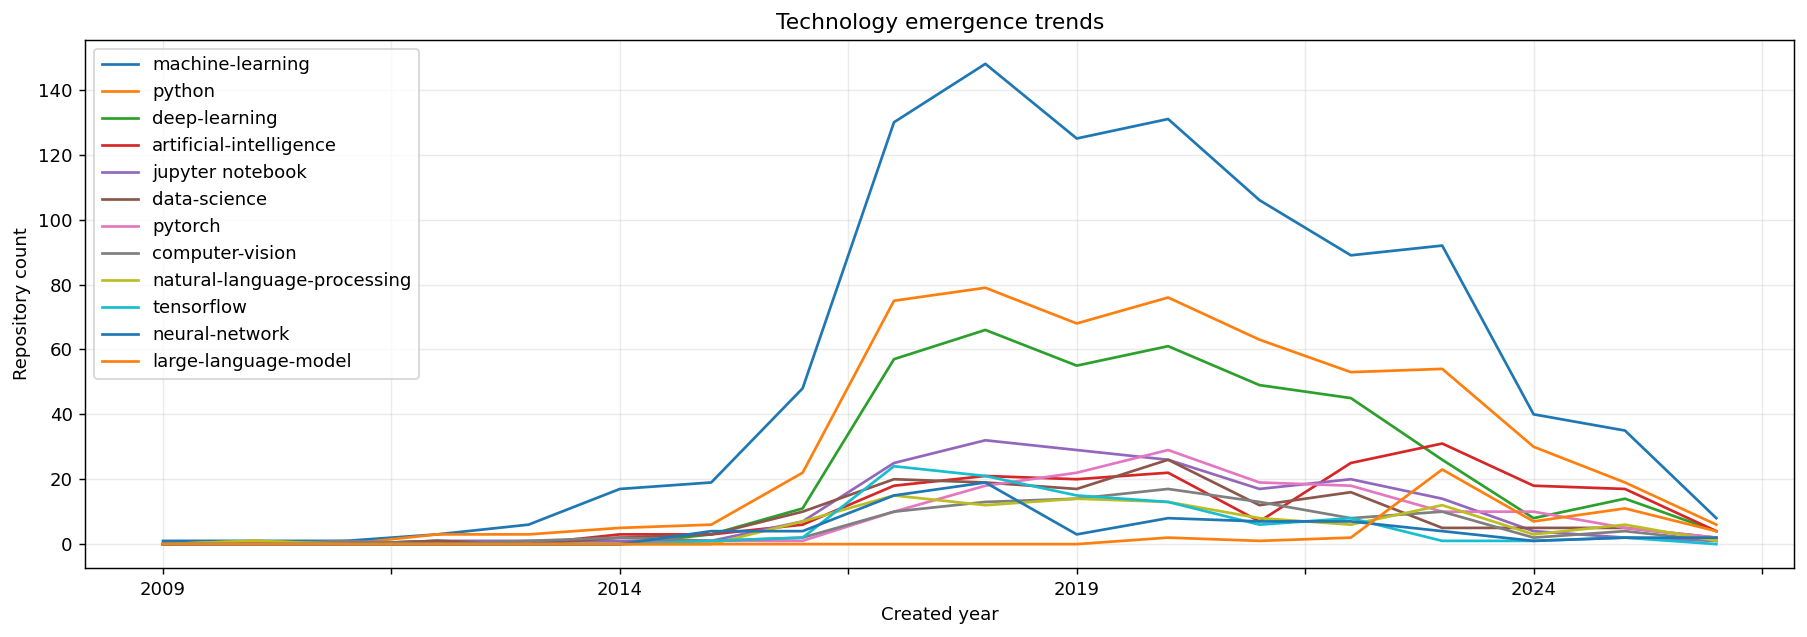

In [42]:
trend_data = stats.get("trends", {})
trend_df = pd.DataFrame(trend_data).fillna(0).sort_index()
display(trend_df.tail(10))

if not trend_df.empty:
    trend_df.plot(figsize=(14, 5), title="Technology emergence trends")
    plt.xlabel("Created year")
    plt.ylabel("Repository count")
    plt.tight_layout()

In [43]:
top_language = pd.Series(stats["language_distribution"]).idxmax()
top_category = pd.Series(stats["category_distribution"]).idxmax()
top_tech = nodes.iloc[0]["id"]
top_rule = rules.iloc[0]

decision_points = [
    f"Most common language: {top_language}",
    f"Largest semantic category: {top_category}",
    f"Most central technology by PageRank: {top_tech}",
    f"Strongest stack rule: {' + '.join(top_rule['antecedent'])} -> {' + '.join(top_rule['consequent'])}",
    "Use association rules to recommend complementary technologies.",
    "Use PageRank/HITS to prioritize central ecosystem skills.",
    "Use semantic similarity to find comparable projects for learning or reuse.",
]

for point in decision_points:
    print("-", point)

- Most common language: Python
- Largest semantic category: AI/ML Infrastructure
- Most central technology by PageRank: machine-learning
- Strongest stack rule: deep-reinforcement-learning -> reinforcement-learning
- Use association rules to recommend complementary technologies.
- Use PageRank/HITS to prioritize central ecosystem skills.
- Use semantic similarity to find comparable projects for learning or reuse.


## 14. Dashboard GUI

The dashboard is a complete GUI for the project. It includes:

- KPI overview
- filters for category, language, popularity, and search
- language/category/era charts
- technology trend chart
- PageRank and HITS charts
- D3 co-occurrence network graph
- association rule visualization
- BERT classification diagnostics
- PCA cluster map
- recommendation engine
- paginated large-data repository explorer

In [44]:
print("Start the dashboard from the project root:")
print("python3 -m http.server 8080")
print("Open: http://127.0.0.1:8080/app/")

Start the dashboard from the project root:
python3 -m http.server 8080
Open: http://127.0.0.1:8080/app/


## 14.1 Grading Evidence Matrix

This matrix maps every requested rubric item to concrete files and computed outputs.

In [45]:
grading_evidence = pd.DataFrame([
    {
        "rubric_item": "Data Collection and GUI",
        "evidence": "GitHub API collector, large raw JSON dataset, dashboard app",
        "file_or_output": "scripts/collect_data.py, data/raw/github_repos.json, app/index.html",
        "status": "complete",
    },
    {
        "rubric_item": "Data Preprocessing",
        "evidence": "cleaned text, normalized topics, tech_stack, era/popularity features",
        "file_or_output": "scripts/run_pipeline.py, data/processed/repos.json",
        "status": "complete",
    },
    {
        "rubric_item": "Association Rule Mining",
        "evidence": f"{stats['total_rules']:,} Apriori rules with support/confidence/lift",
        "file_or_output": "data/processed/association_rules.json",
        "status": "complete",
    },
    {
        "rubric_item": "Link Analysis",
        "evidence": f"PageRank/HITS over {stats['total_technologies']:,} technology nodes and repository influence graph",
        "file_or_output": "data/processed/graph_nodes.json",
        "status": "complete",
    },
    {
        "rubric_item": "Visualization",
        "evidence": "Notebook plots, Chart.js charts, D3 network, PCA projection",
        "file_or_output": "github_mining_analysis.ipynb, app/",
        "status": "complete",
    },
    {
        "rubric_item": "BERT",
        "evidence": "Real pretrained BERT-Tiny embeddings, classification, clustering, recommendations",
        "file_or_output": "scripts/run_pipeline.py, data/processed/similarities.json",
        "status": "complete",
    },
    {
        "rubric_item": "Report and Presentation",
        "evidence": "Markdown report and presentation outline",
        "file_or_output": "outputs/project_report.md, outputs/presentation_outline.md",
        "status": "complete",
    },
])

display(grading_evidence)

,rubric_item,evidence,file_or_output,status
0,Data Collection and GUI,"GitHub API collector, large raw JSON dataset, dashboard app","scripts/collect_data.py, data/raw/github_repos.json, app/index.html",complete
1,Data Preprocessing,"cleaned text, normalized topics, tech_stack, era/popularity features","scripts/run_pipeline.py, data/processed/repos.json",complete
2,Association Rule Mining,265 Apriori rules with support/confidence/lift,data/processed/association_rules.json,complete
3,Link Analysis,"PageRank/HITS over 3,388 technology nodes and repository influence graph",data/processed/graph_nodes.json,complete
4,Visualization,"Notebook plots, Chart.js charts, D3 network, PCA projection","github_mining_analysis.ipynb, app/",complete
5,BERT,"Real pretrained BERT-Tiny embeddings, classification, clustering, recommendations","scripts/run_pipeline.py, data/processed/similarities.json",complete
6,Report and Presentation,Markdown report and presentation outline,"outputs/project_report.md, outputs/presentation_outline.md",complete


## 15. Report-Ready Results

These are the main results to include in the written report and slides.

In [46]:
print("Main metrics")
print("------------")
print(f"Repositories: {stats['total_repos']:,}")
print(f"Technologies: {stats['total_technologies']:,}")
print(f"Graph edges: {stats['total_edges']:,}")
print(f"Communities: {stats['total_communities']:,}")
print(f"Rules: {stats['total_rules']:,}")
print(f"Categories: {stats['total_categories']:,}")
print(f"Average semantic confidence: {stats['average_bert_confidence']}")

print("\nKey insights")
print("------------")
for insight in stats.get("insights", []):
    print("-", insight)

Main metrics
------------
Repositories: 1,000
Technologies: 3,388
Graph edges: 1,500
Communities: 3
Rules: 265
Categories: 11
Average semantic confidence: 0.5607

Key insights
------------
- machine-learning is the most central technology by PageRank, appearing in 1000 repositories.
- The strongest association rule is deep-reinforcement-learning -> reinforcement-learning with lift 18.57143 and confidence 0.92857.
- AI/ML Infrastructure is the largest semantic category with 757 repositories.


## 16. Limitations and Future Work

Limitations:

- GitHub API collection depends on token quota and rate limits.
- GitHub API collection without a token is smaller because public unauthenticated requests are rate-limited.
- The default real BERT-Tiny path downloads a compact Hugging Face model; larger SentenceTransformer models can improve embedding quality when compute is available.
- Repository relationships based on shared technologies can be dense, so the notebook caps graph edges for interpretability.

Future work:

- Collect real data nightly with GitHub Actions.
- Add temporal trend forecasting.
- Add community detection with Louvain or Leiden.
- Add a real vector database for semantic search.
- Use full README embeddings with a fine-tuned BERT classifier.

## 17. Presentation Outline

1. Problem statement and project objective
2. Data collection from GitHub
3. Dataset profile and preprocessing
4. Association rule mining with Apriori
5. Link analysis with PageRank and HITS
6. BERT-based classification and semantic similarity
7. Dashboard demonstration
8. Key insights and decision support
9. Limitations and future improvements
10. Conclusion

## 18. Conclusion

This project provides an end-to-end data mining workflow for GitHub repository mining. It combines web mining, transaction mining, graph mining, semantic text mining, visualization, and recommendations into a single reproducible project with both a notebook and an interactive app.